In [2]:
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import copy

c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
all_party_textes_df = pd.read_parquet("all_parties_text_combined_prep_classified.parquet")
labled_theses_df = pd.read_parquet('wahlomat_thesen_prep.parquet')
Labled_theses_classification_df = pd.read_parquet('wahlomaten_thesen_positionen_classified.parquet')

labled_theses_df['Predicted_Class'] = Labled_theses_classification_df['Predicted_Class']
del Labled_theses_classification_df


In [6]:
print(all_party_textes_df.columns)
print(labled_theses_df.columns)

Index(['Party', 'Chapter', 'These', 'Text', 'Text_no_stopwords',
       'These_no_stopwords', 'Text_lemmatized', 'These_lemmatized',
       'These_unique_words', 'These_Word_Count', 'Text_Word_Count',
       'Total_Word_Count', 'Predicted_Class'],
      dtype='object')
Index(['These', 'These_no_stopwords', 'These_lemmatized', 'These_unique_words',
       'CDU / CSU', 'GRÜNE', 'SPD', 'AfD', 'Die Linke', 'FDP',
       'Predicted_Class'],
      dtype='object')


In [8]:
lable_colums_list = labled_theses_df.columns[1:].tolist()

replace_dict = {
    'spd'   :   'SPD', 
    'cdu'   :   'CDU / CSU', 
    'gruene':   'GRÜNE', 
    'afd'   :   'AfD',
    'fdp'   :   'FDP', 
    'linke' :   'Die Linke'
}

all_party_textes_df['Party'] = all_party_textes_df['Party'].replace(replace_dict)
del replace_dict

In [ ]:
# Load tokenizer and model
model_name = "mmmaurer/sbert-hashtag-german-politicians-2021"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)



def get_embedding(text:str, pooling_method:str = 'mean'):
    # Tokenize the input
    inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")

    # Get model output (embeddings)
    outputs = model(**inputs)

    # Extract the embeddings from the model output
    match pooling_method:
        case 'mean':
            return outputs.last_hidden_state.mean(dim=1).squeeze().detach().numpy()
        case 'max':
            return outputs.last_hidden_state.max(dim=1).values.squeeze().detach().numpy()
        case _:
            raise ValueError(f'The used pooling method ({pooling_method}) is not supported. Use "mean" or "max".')




In [ ]:
#(all_party_textes_df:pd.DataFrame, labled_theses_df:pd.DataFrame, content:str = 'These', plot:bool = False)
def similarity_func(all_party_textes_df:pd.DataFrame, 
                    labled_theses_df:pd.DataFrame, 
                    lable_text_column:str, 
                    party_text_column:str,
                    plot:bool = False, 
                    sort_by_classification:bool = False, 
                    pooling_method:str='mean'):
    
    # Liste der Parteien und Thesen
    all_party_textes_df['Chapter'] = all_party_textes_df['Chapter'].fillna('-')
    parties_list = all_party_textes_df['Party'].unique().tolist()
    predicted_theses_df = copy.deepcopy(labled_theses_df)
    
    labled_text_list = labled_theses_df[lable_text_column].tolist()
    predicted_theses_dfs_dict = {}

    # Schleife über die Parteien
    for party_str in parties_list:
        # Filtern der Daten für die aktuelle Partei
        party_df = all_party_textes_df[all_party_textes_df['Party'] == party_str]

        # Entfernen von Zeilen mit NaN-Werten
        party_df = party_df.dropna()

        # Extrahieren der Thesen für die aktuelle Partei
        party_text_list = party_df[party_text_column].to_list()

        # Erstellung eines DataFrames zur Berechnung der Ähnlichkeiten
        similarity_df = pd.DataFrame(columns=['party_text'] + labled_text_list)

        # Berechnung der Ähnlichkeit für jede Partei-These
        for party_text in party_text_list:
            party_text_embedding = get_embedding(party_text, pooling_method = pooling_method)
            row = [party_text]
            party_domain_num = party_df[party_df[party_text_column]==party_text]['Predicted_Class'].str[0].values[0]
            # Berechnung der Kosinusähnlichkeit für jede labelte These
            for label_text in labled_text_list:
                lable_domain_num = labled_theses_df[labled_theses_df[lable_text_column]==label_text]['Predicted_Class'].str[0].values[0] #labled_theses_df[lable_text_column]
                label_text_embedding = get_embedding(label_text, pooling_method = pooling_method)
                similarity_score = (cosine_similarity(party_text_embedding.reshape(1, -1), label_text_embedding.reshape(1, -1))[0][0])
                if lable_domain_num != party_domain_num and sort_by_classification:
                    similarity_score = 0
                row.append(similarity_score)

            similarity_df.loc[len(similarity_df)] = row

        if plot:
            # Visualisierung der Ähnlichkeiten als Heatmap
            plt.figure(figsize=(18, 18))
            sns.heatmap(similarity_df[labled_text_list],
                        cmap='RdYlGn',
                        annot=False,
                        vmax=1,
                        vmin=0,
                        yticklabels=party_df["These"])
            plt.xticks(rotation=45, ha="right")
            plt.title(f"Thesen-Heatmap: {party_str}")
            plt.show()

        # Maximale Ähnlichkeit für jede Partei
        predicted_theses_dfs_dict[party_str] = similarity_df
        predicted_theses_df[party_str] = similarity_df[labled_text_list].max().tolist()

    return predicted_theses_dfs_dict, predicted_theses_df
    
   

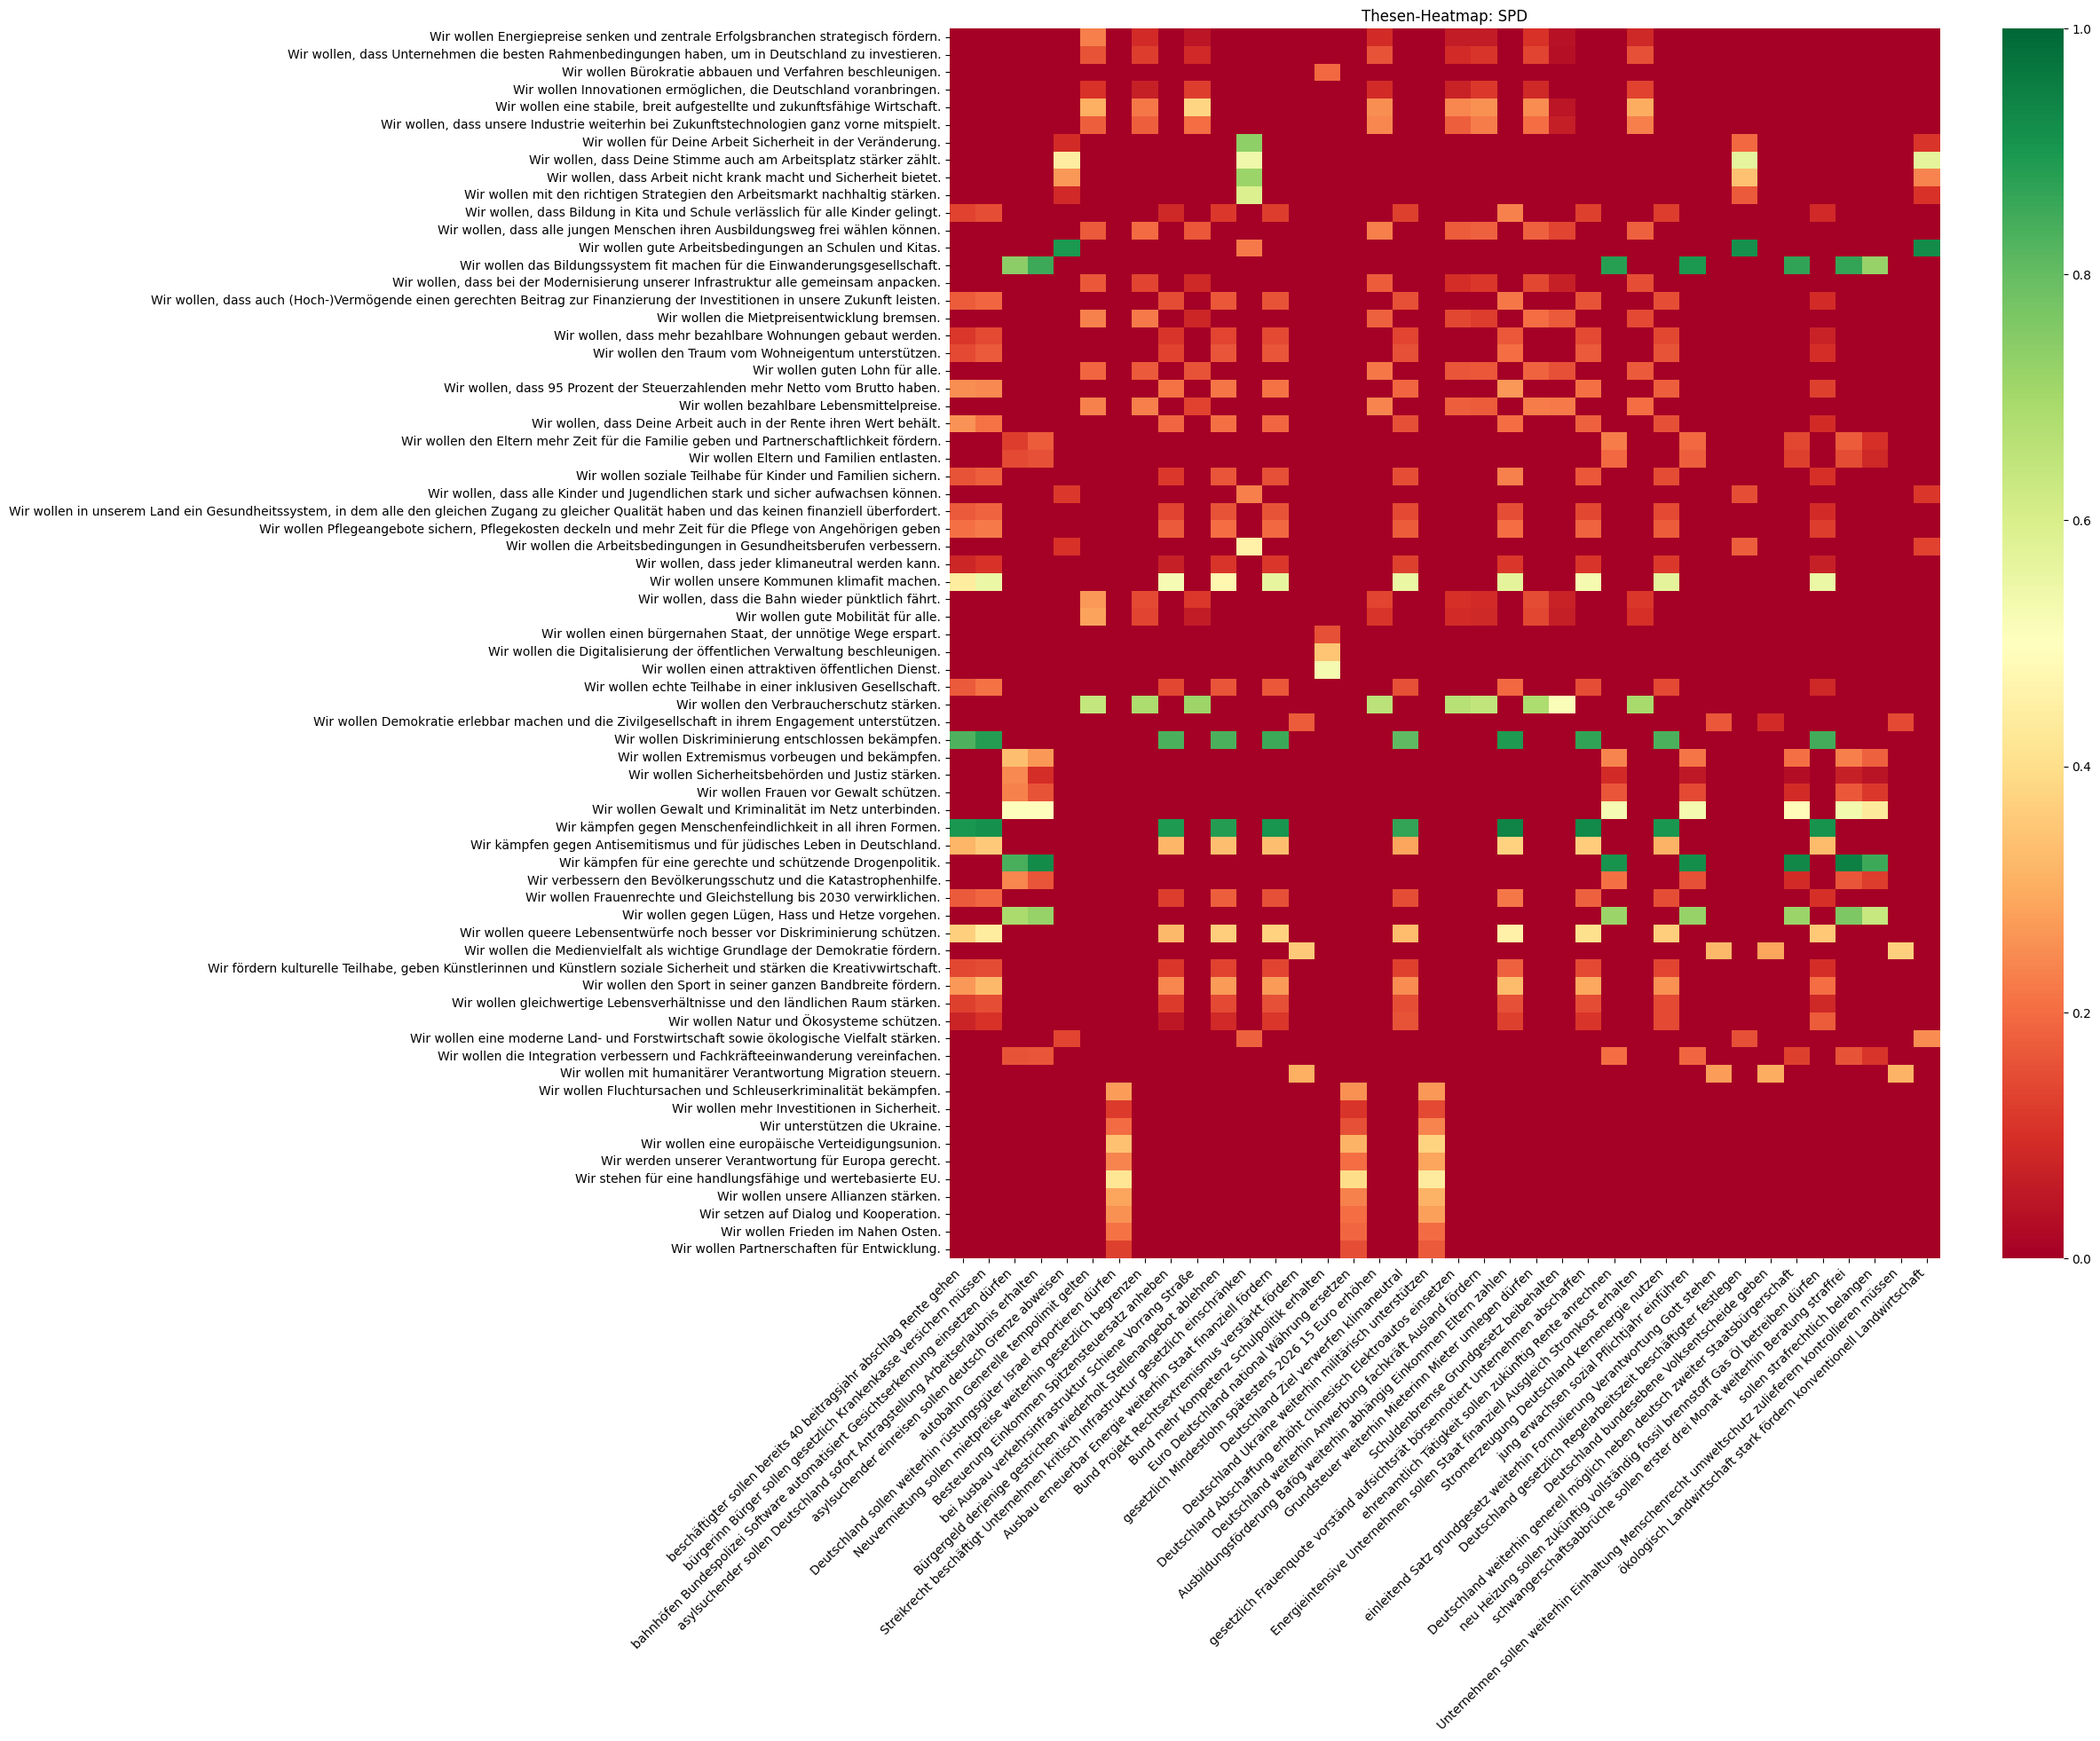

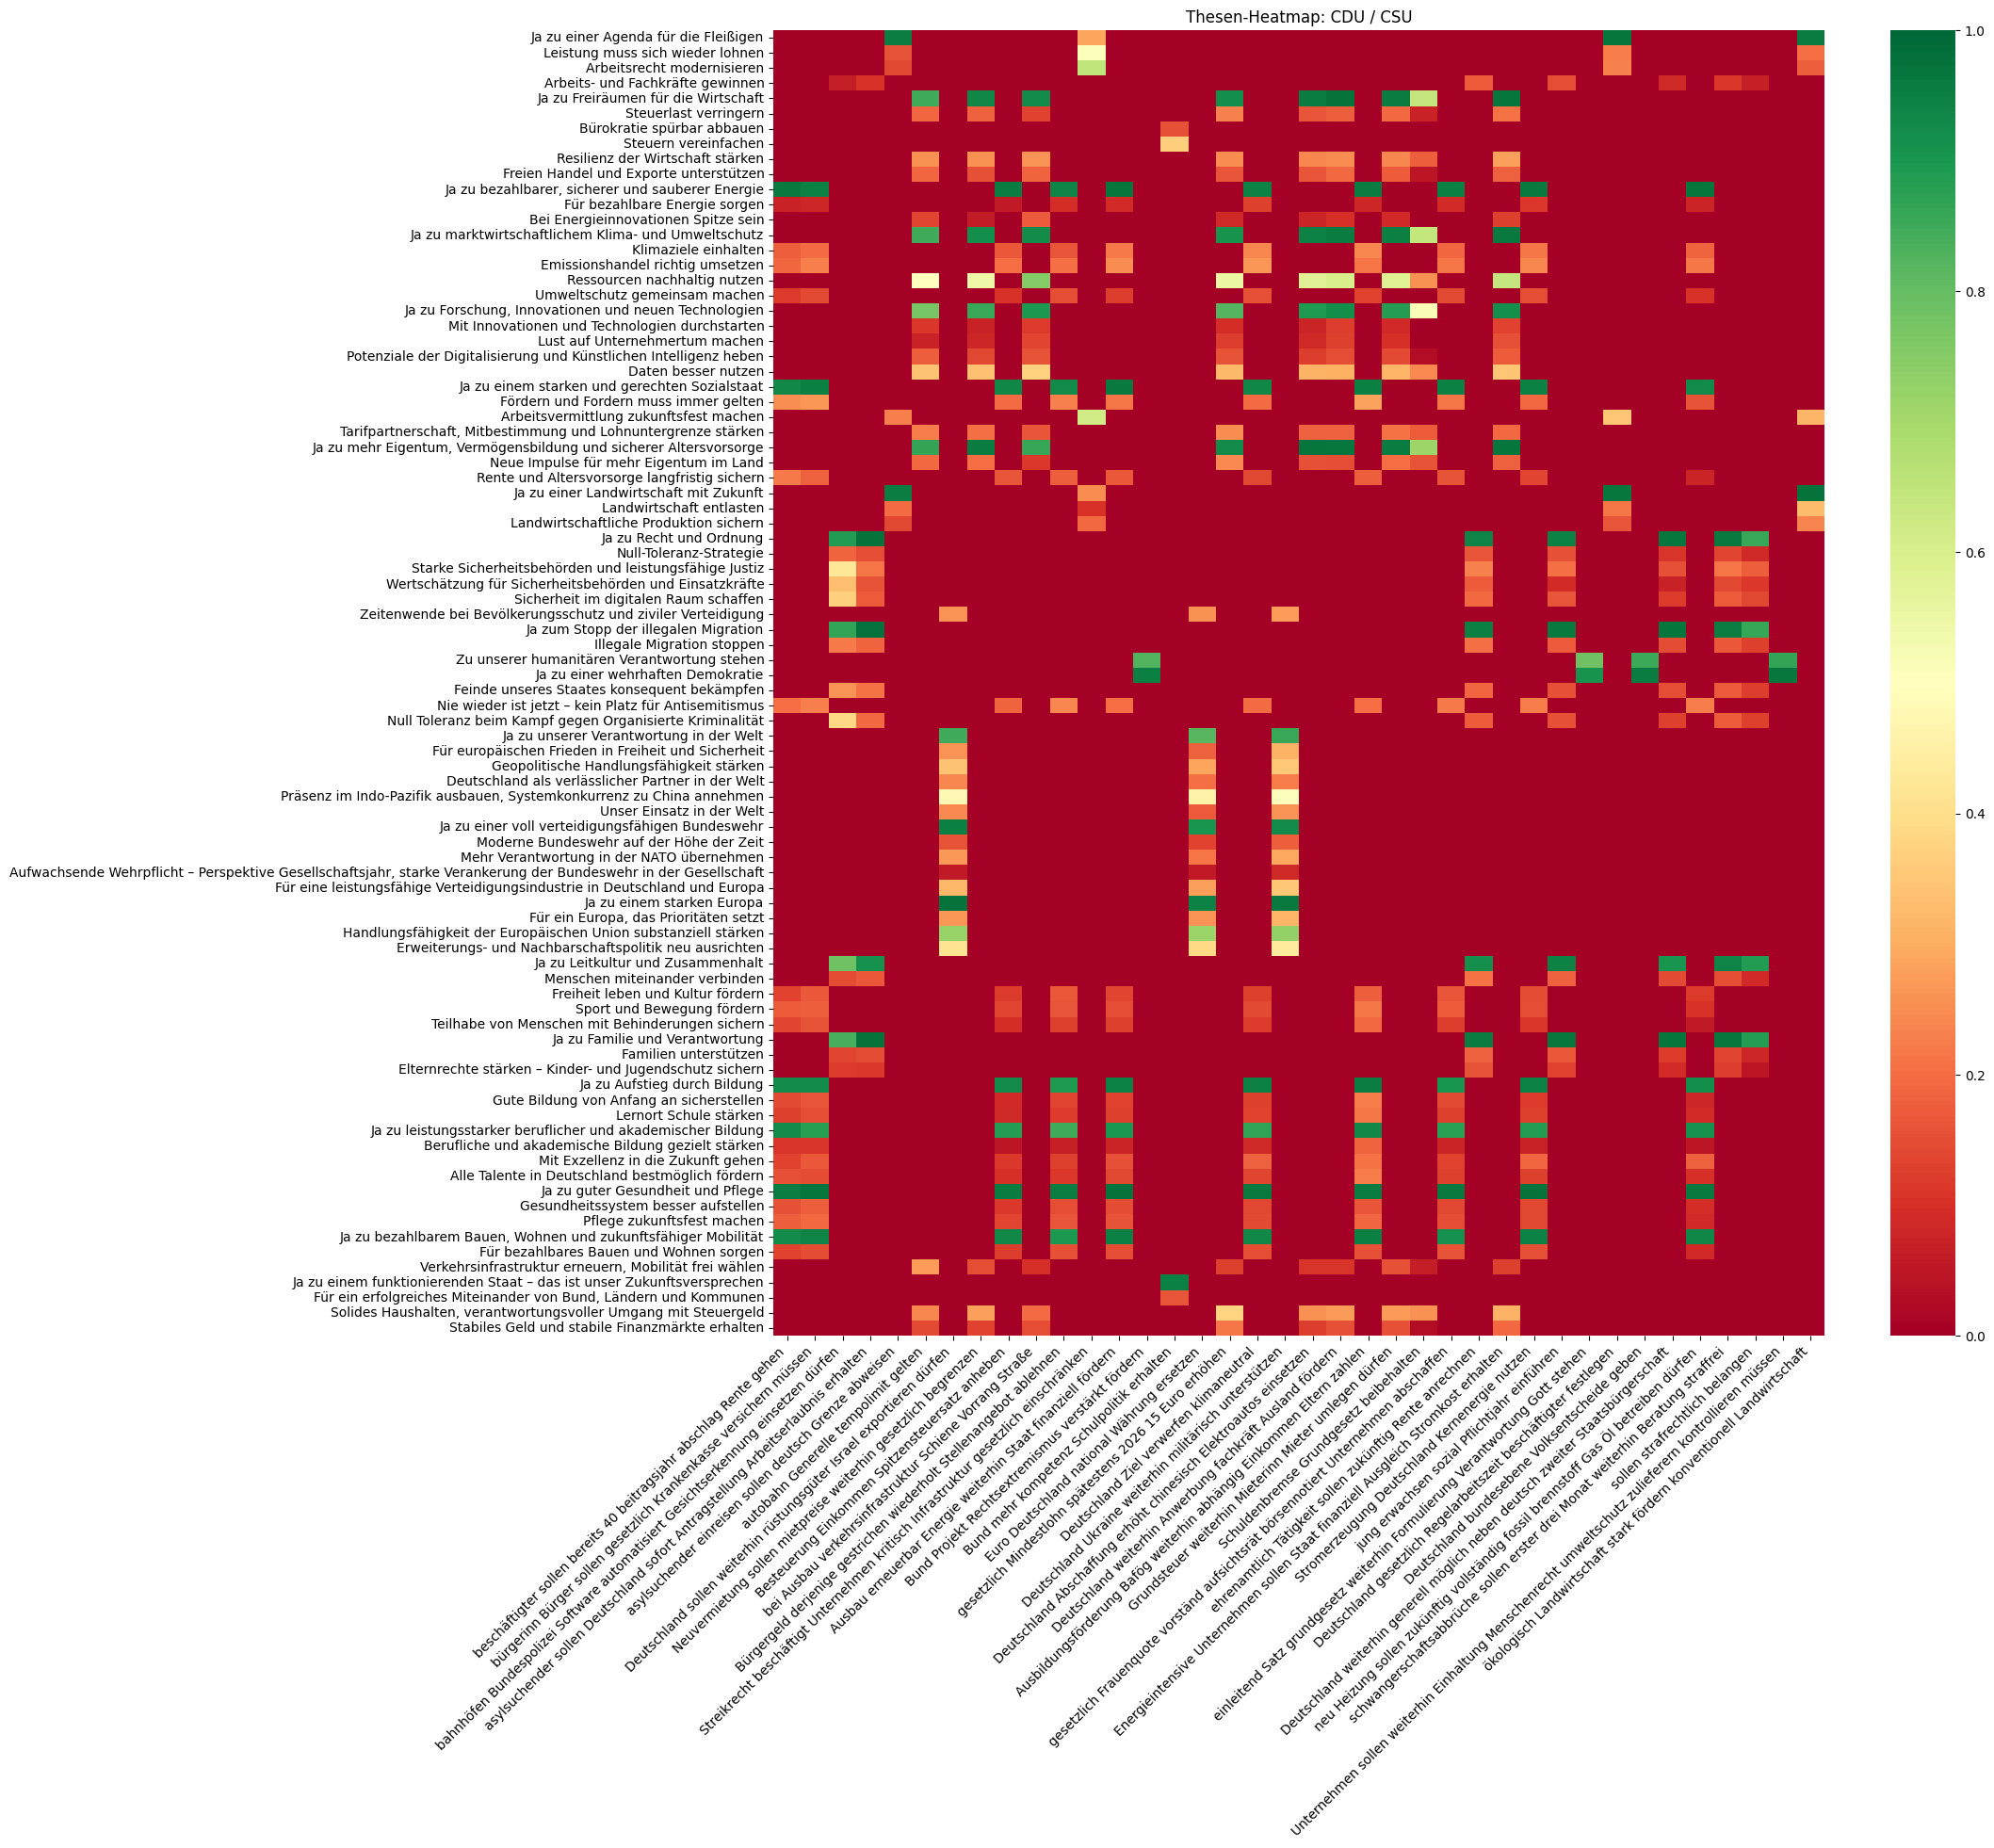

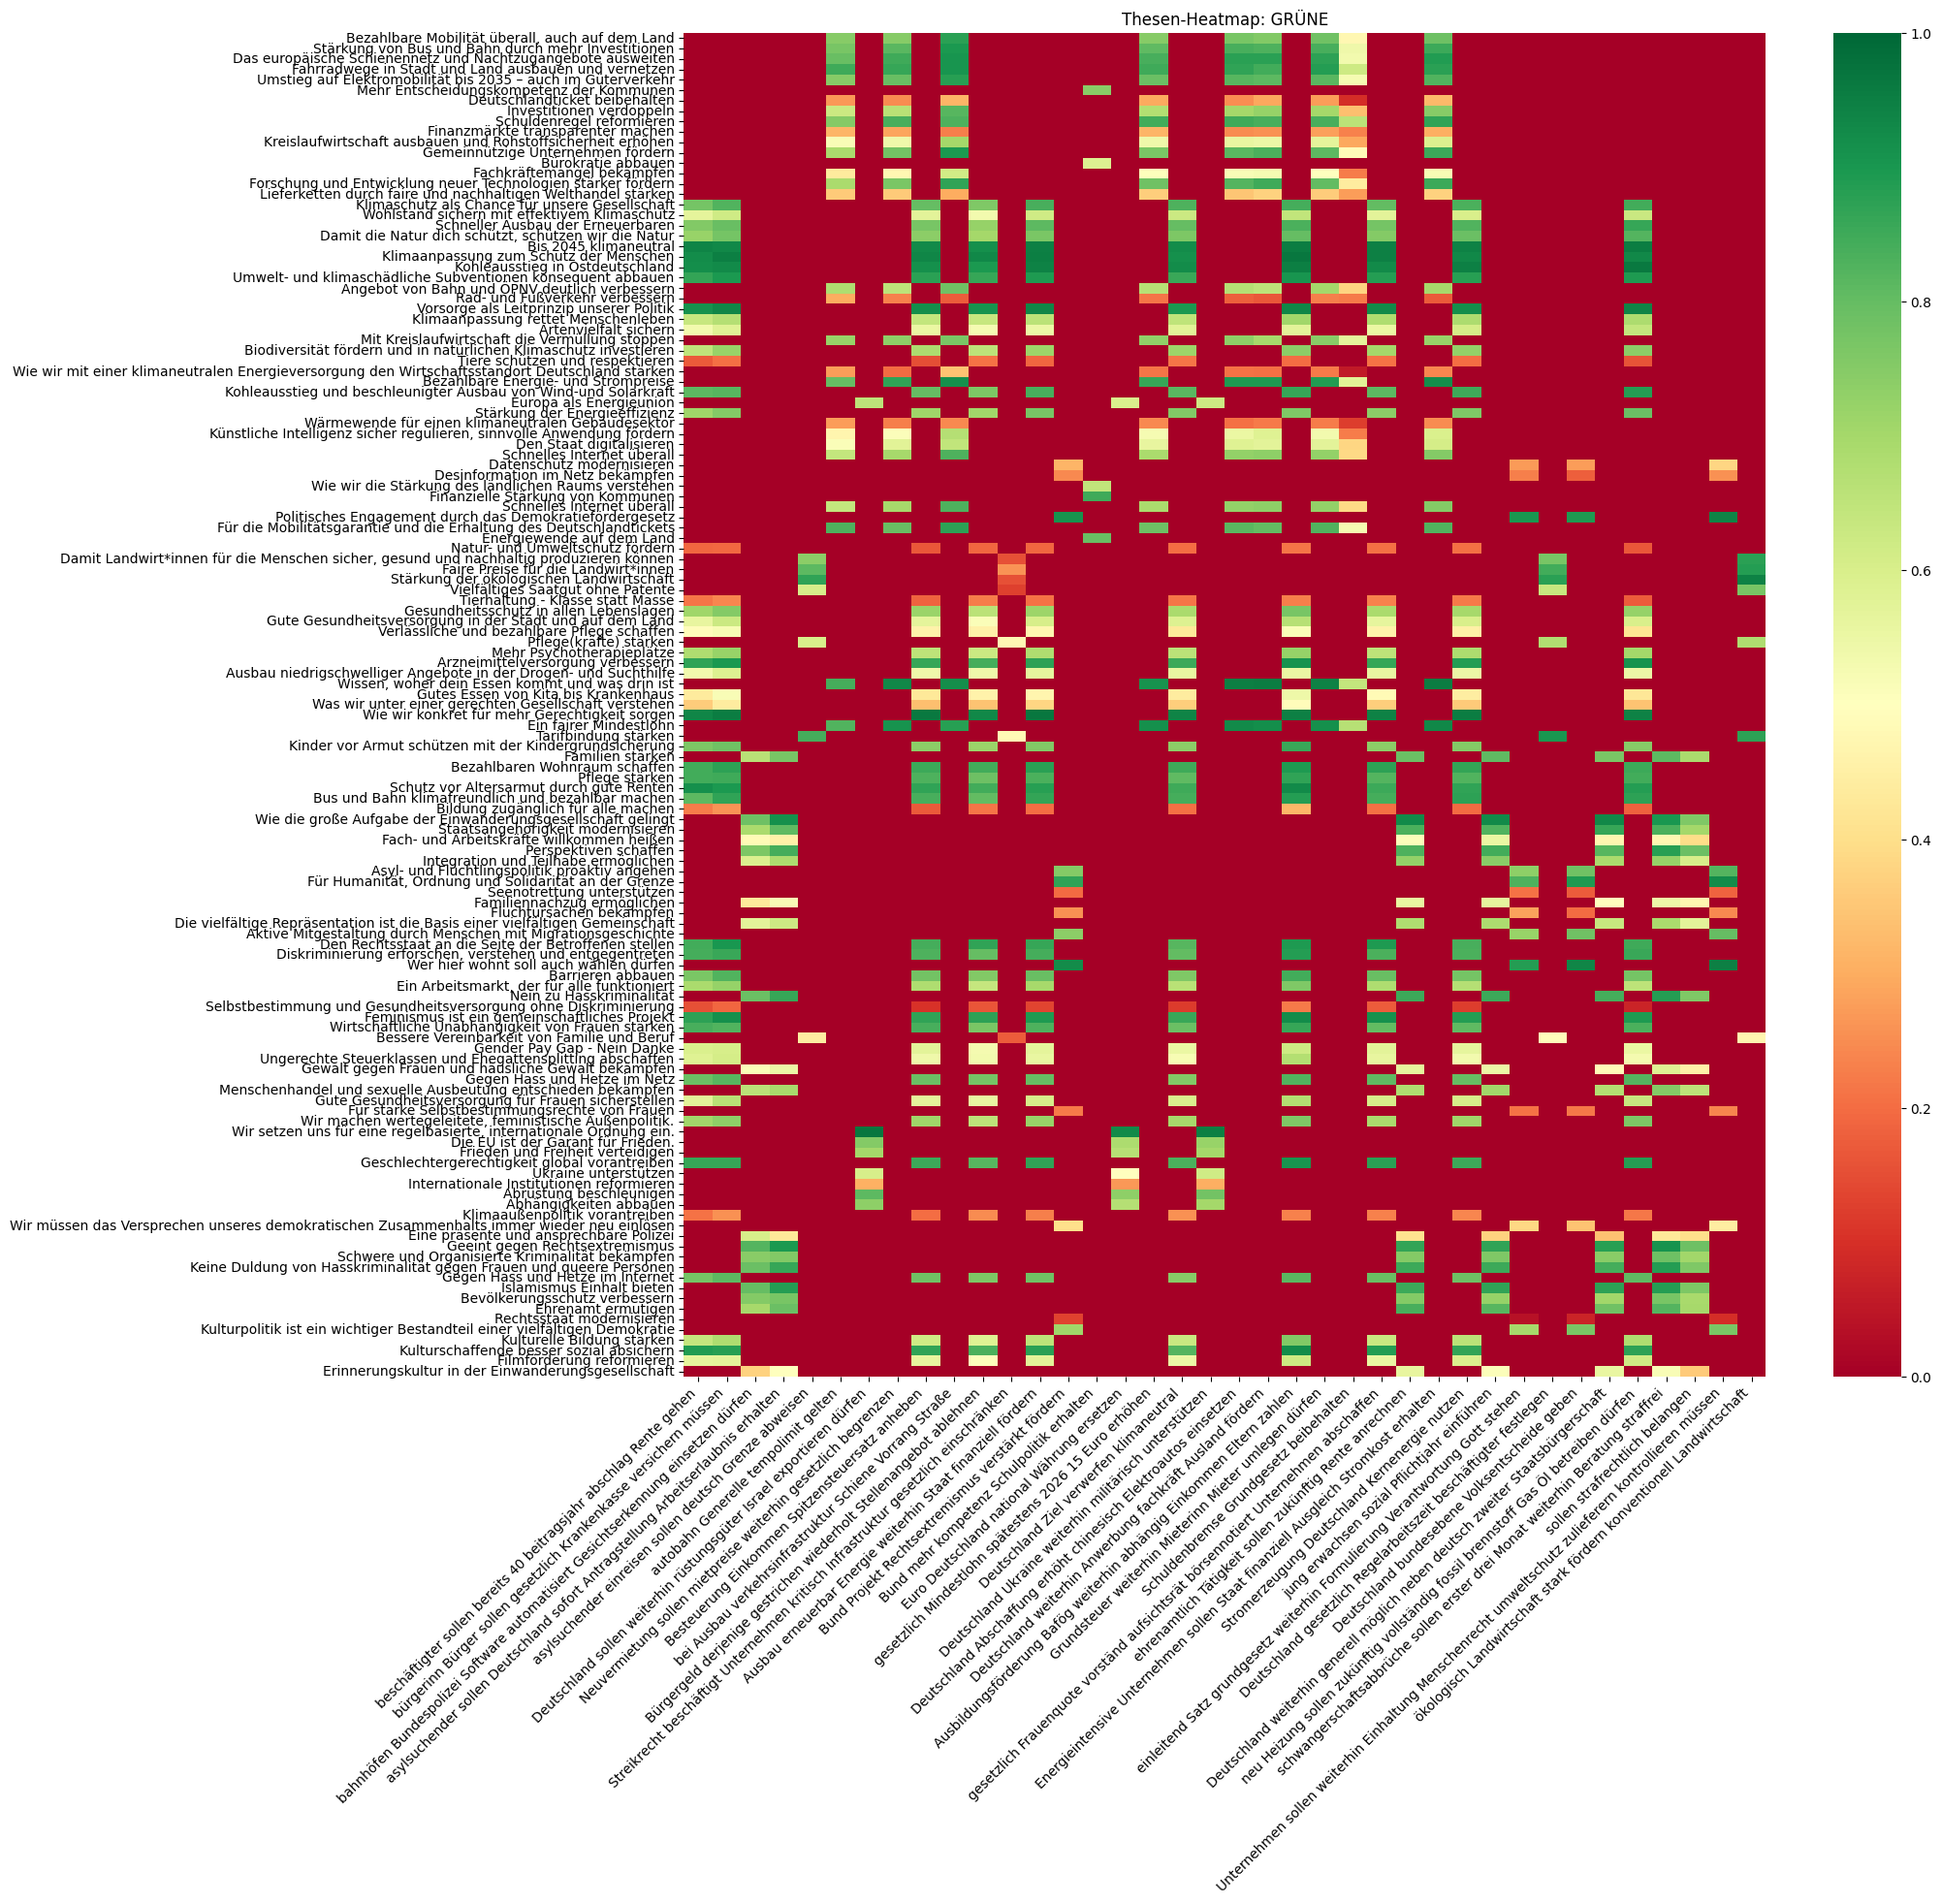

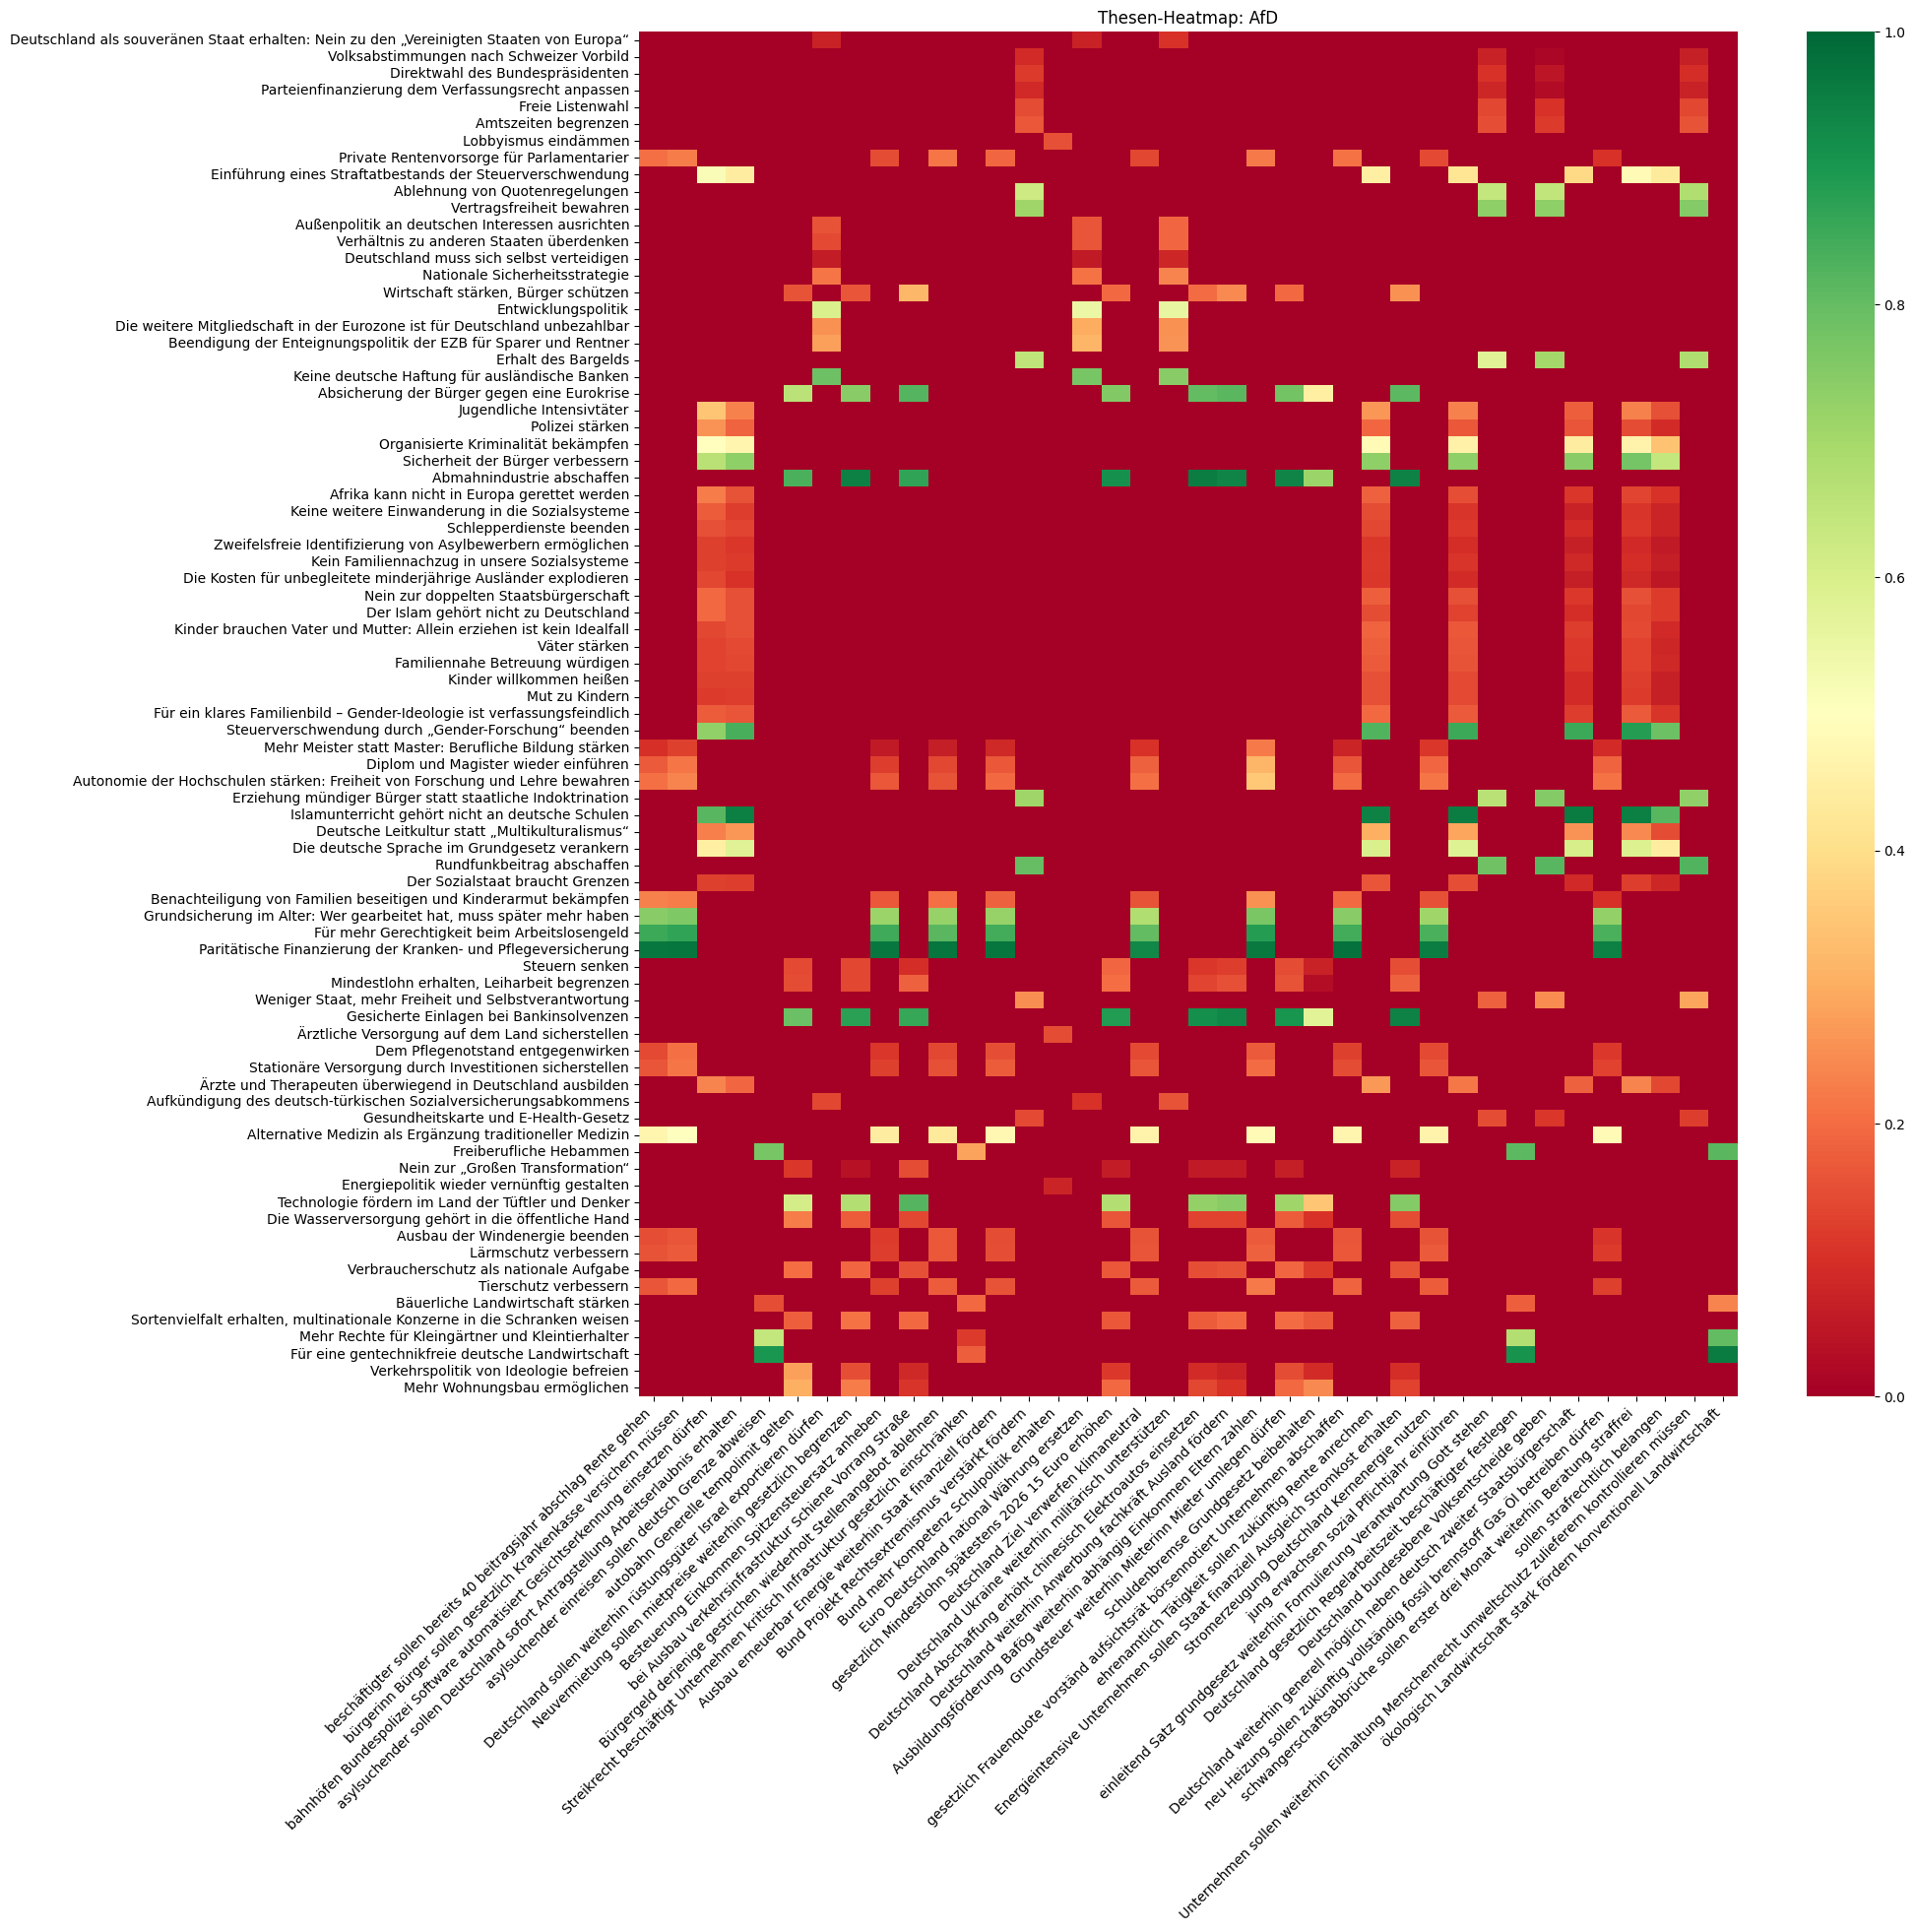

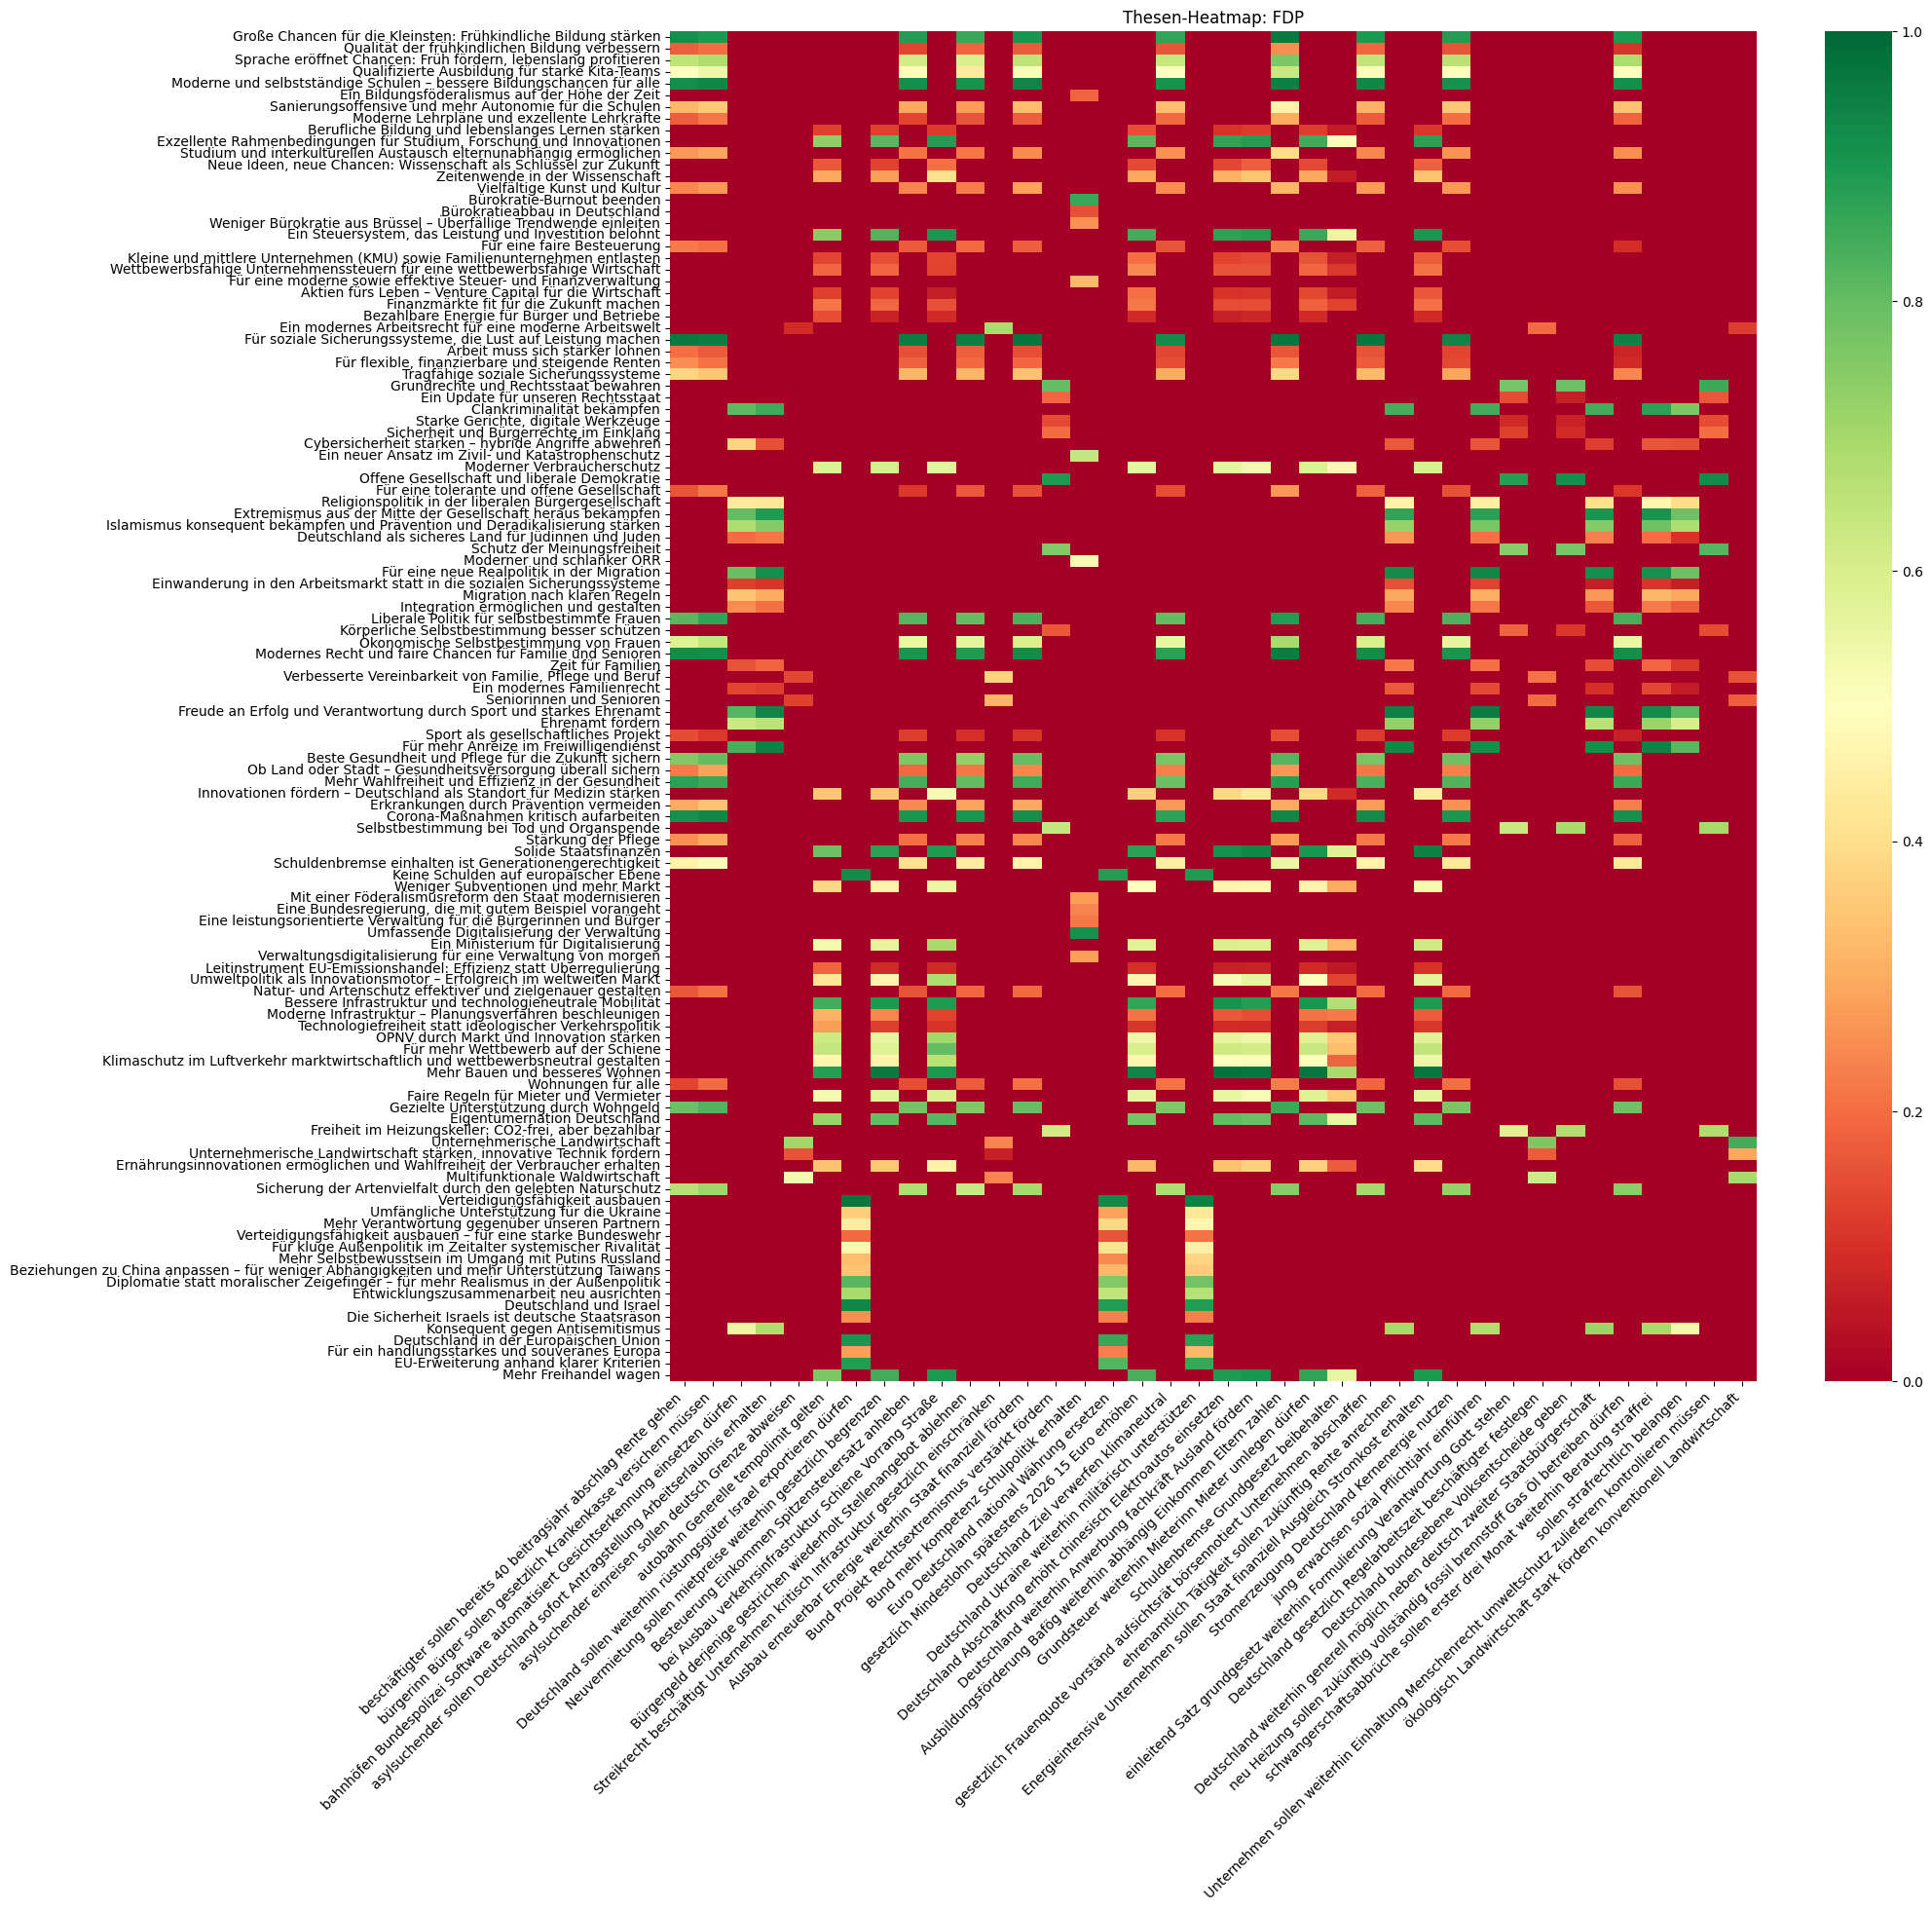

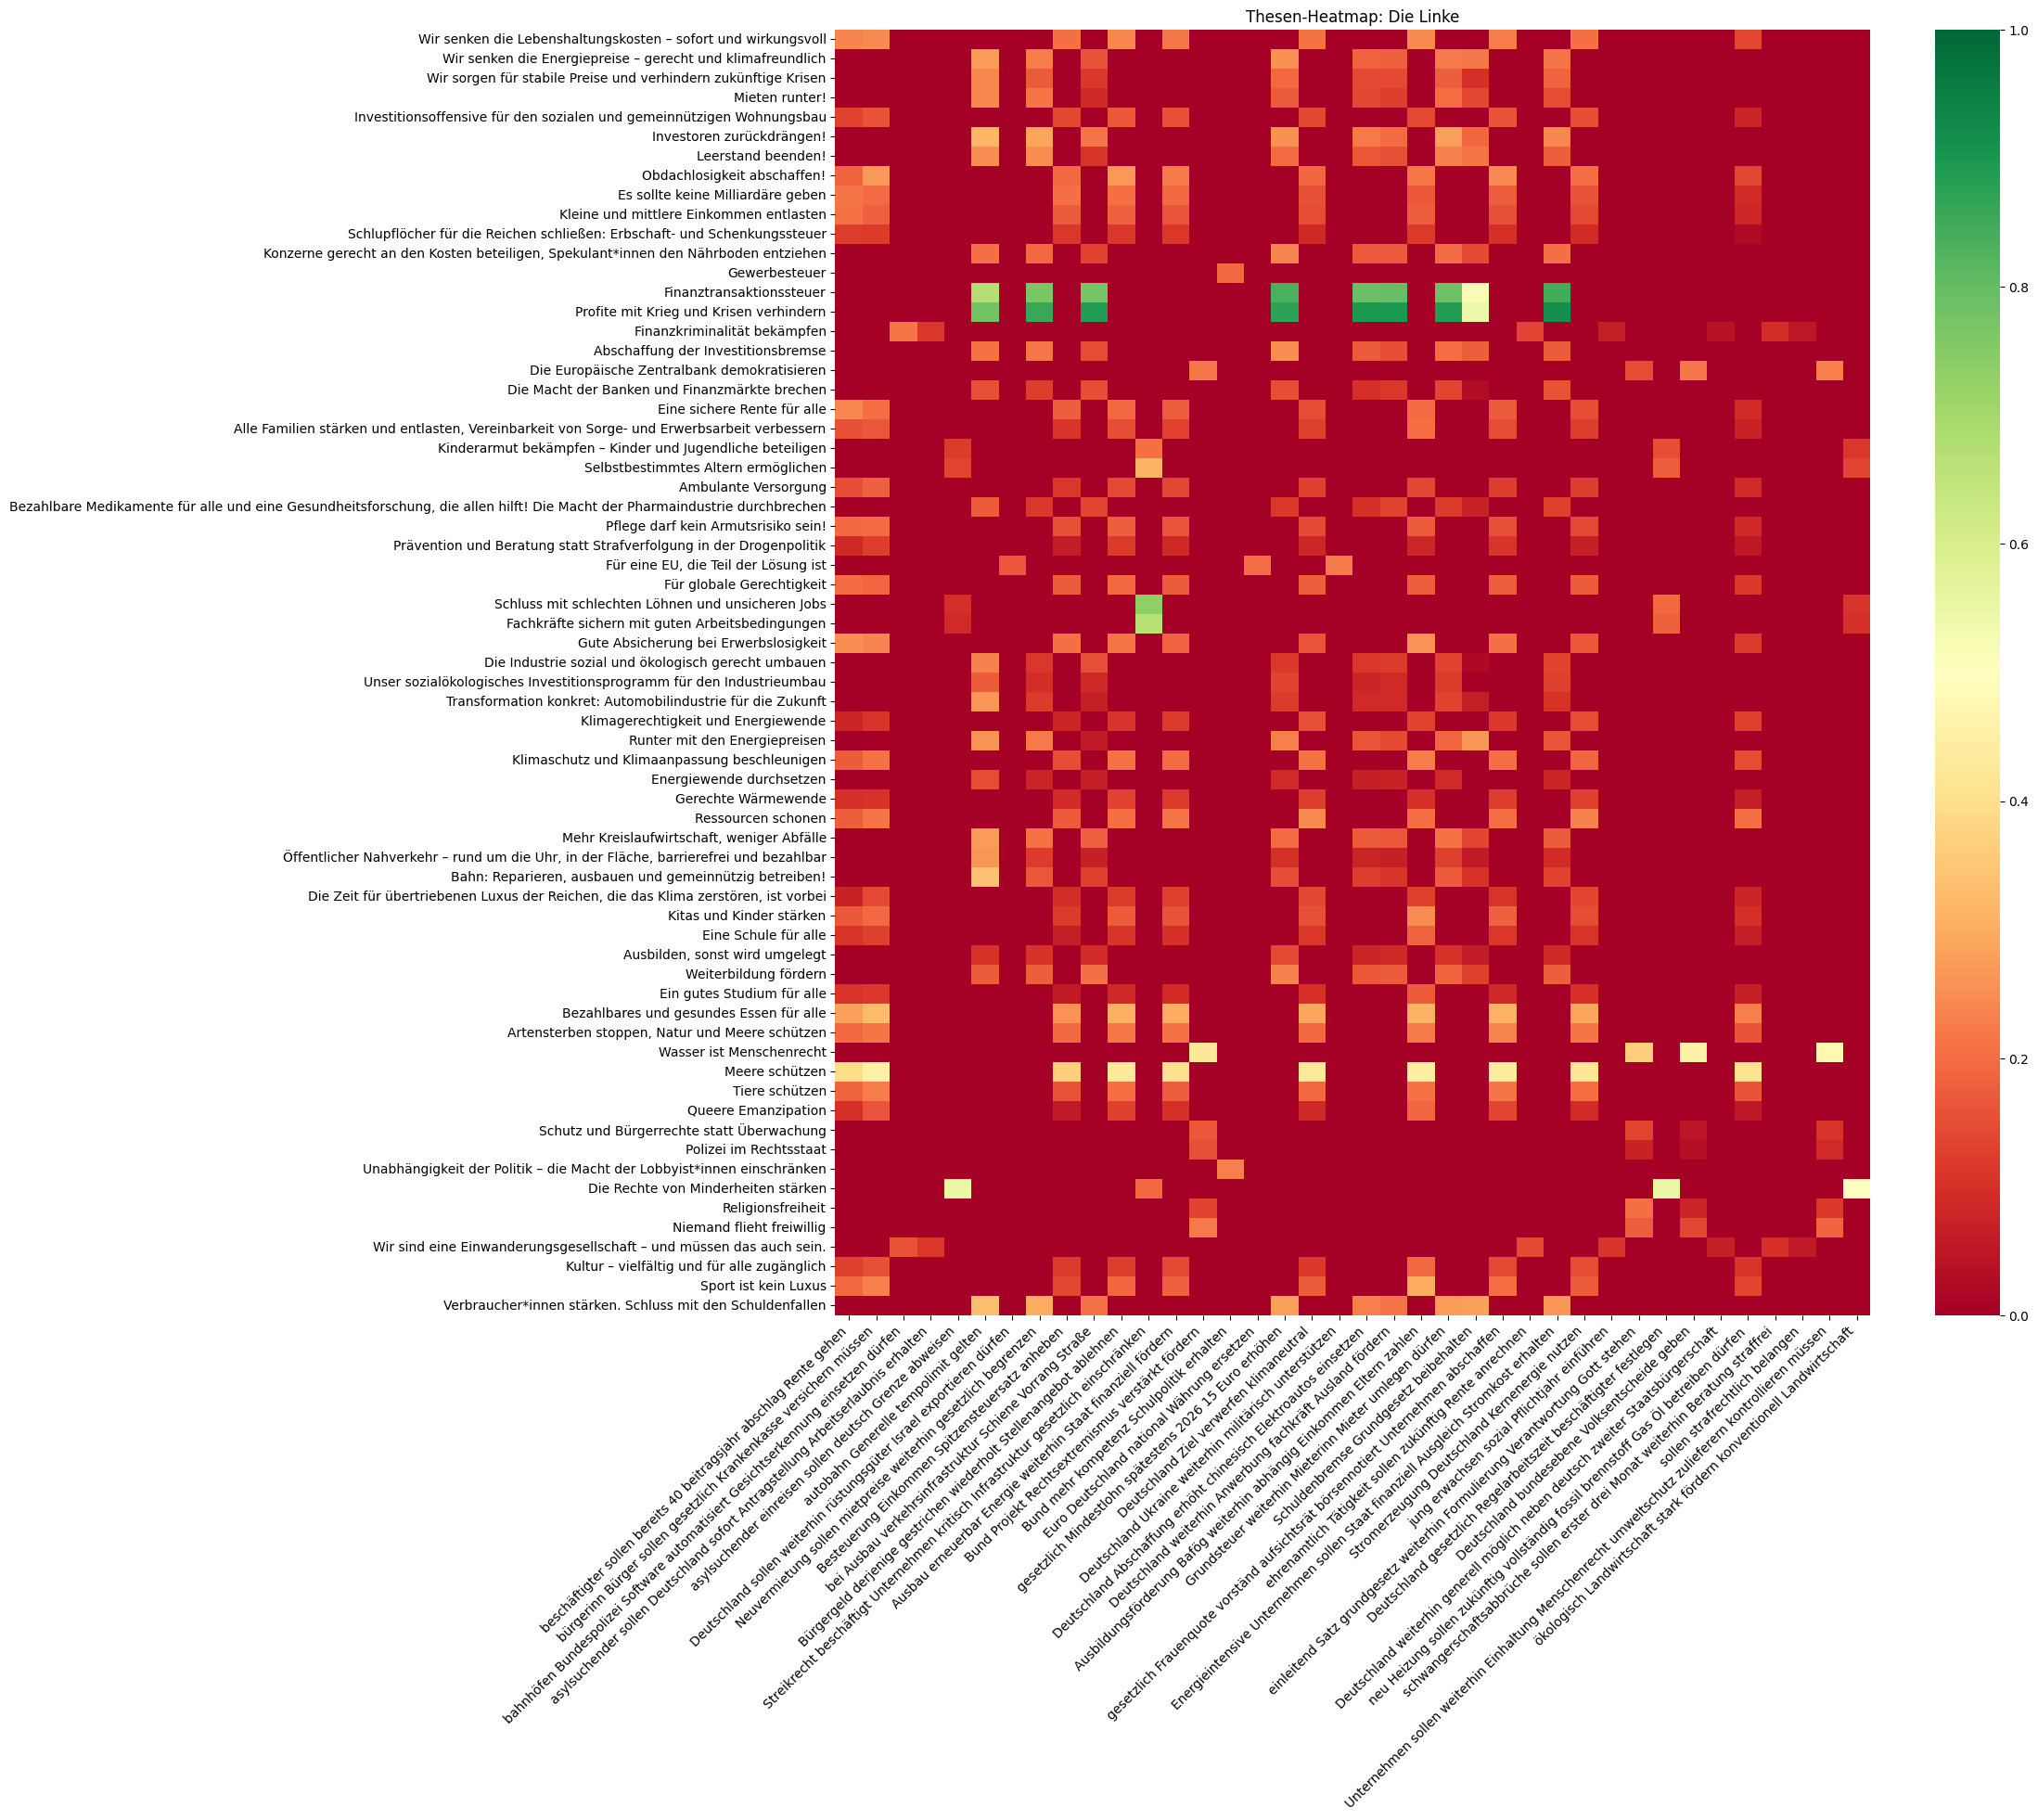

In [52]:
lable_text_column = 'These_lemmatized'
party_text_column = 'Text_lemmatized'
predicted_theses_dfs_dict, predicted_theses_df = similarity_func(all_party_textes_df,labled_theses_df,lable_text_column,party_text_column, plot=True, sort_by_classification=True)


Dieses NB:  
-> Funktion die die similarity ausgibt
-> Funktion die lables verteilt (Möglichkeit 1 und 2)  
-> Funktion die predicted Lable mit den true lable (confusion, acuraccy...)  
-> für alle modelle und Text-Kombinationen laufen lassen  

Neues NB:  
-> Funktion die similarity wie folgt ausgibt:    
    if label_category = party_category & sim score>=60  
        lable = stimme zu   
    elif abel_category = party_oposit_category & sim score>=60  
        lable = stimme nicht zu  
    else  
        lable = neutral  

-> Funktion die predicted Lable mit den true lable (confusion, acuraccy...)  
-> für alle modelle und Text-Kombinationen laufen lassen 

In [53]:
display(predicted_theses_df)

,These,These_no_stopwords,These_lemmatized,These_unique_words,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP,Predicted_Class
0,Alle Beschäftigten sollen bereits nach 40 Beit...,beschäftigten sollen bereits 40 beitragsjahren...,beschäftigter sollen bereits 40 beitragsjahr a...,beschäftigter sollen bereits 40 beitragsjahr a...,0.962512,0.938636,0.899766,0.965782,0.397355,0.962983,504 - Welfare State Expansion
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,bürgerinnen bürger sollen gesetzlichen kranken...,bürgerinn Bürger sollen gesetzlich Krankenkass...,bürgerinn Bürger sollen gesetzlich Krankenkass...,0.970416,0.955666,0.910952,0.969547,0.456947,0.954334,504 - Welfare State Expansion
2,An Bahnhöfen soll die Bundespolizei Software z...,bahnhöfen bundespolizei software automatisiert...,bahnhöfen Bundespolizei Software automatisiert...,bahnhöfen Bundespolizei Software automatisiert...,0.886722,0.822612,0.837915,0.819789,0.211306,0.837813,605 - Law and Order: Positive
3,Asylsuchende sollen in Deutschland sofort nach...,asylsuchende sollen deutschland sofort antrags...,asylsuchender sollen Deutschland sofort Antrag...,asylsuchender sollen Deutschland sofort Antrag...,0.976928,0.917511,0.924830,0.952186,0.113132,0.946283,602 - National Way of Life: Negative
4,"Asylsuchende, die über einen anderen EU-Staat ...",asylsuchende eingereist sollen deutschen grenz...,asylsuchender einreisen sollen deutsch Grenze ...,asylsuchender einreisen sollen deutsch Grenze ...,0.954652,0.870280,0.897872,0.901188,0.550789,0.705962,705 - Underprivileged Minority Groups
5,Auf allen Autobahnen soll ein generelles Tempo...,autobahnen generelles tempolimit gelten,autobahn Generelle tempolimit gelten,autobahn Generelle tempolimit gelten,0.864220,0.847844,0.644067,0.835338,0.779577,0.881656,411 - Technology and Infrastructure
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,deutschland sollen weiterhin rüstungsgüter isr...,Deutschland sollen weiterhin rüstungsgüter Isr...,Deutschland sollen weiterhin rüstungsgüter Isr...,0.974566,0.966524,0.419544,0.786348,0.165666,0.965274,107 - Internationalism: Positive
7,Bei Neuvermietungen sollen die Mietpreise weit...,neuvermietungen sollen mietpreise weiterhin ge...,Neuvermietung sollen mietpreise weiterhin gese...,Neuvermietung sollen mietpreise weiterhin gese...,0.960311,0.930100,0.683911,0.945936,0.857836,0.963424,412 - Controlled Economy
8,Bei der Besteuerung von Einkommen soll der Spi...,besteuerung einkommen spitzensteuersatz angehoben,Besteuerung Einkommen Spitzensteuersatz anheben,Besteuerung Einkommen Spitzensteuersatz anheben,0.957139,0.964250,0.893859,0.966535,0.370453,0.956623,503 - Equality: Positive
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,beim ausbau verkehrsinfrastruktur schiene vorr...,bei Ausbau verkehrsinfrastruktur Schiene Vorra...,bei Ausbau verkehrsinfrastruktur Schiene Vorra...,0.927553,0.918009,0.712146,0.867325,0.888973,0.899092,411 - Technology and Infrastructure


In [ ]:
party_name = 'AfD'
df = predicted_theses_dfs_dict[party_name]

party_best_simliarities_theses = pd.DataFrame(columns=['Party_These', 'Wahlomat_these', 'similarity', 'Wahlomat_lable'])
#Party_These	Best_Matching_Question	Jaccard_Score
for column in df.columns[1:]:
    max_similarity = df[column].max()
    max_index = df[column].idxmax()
    true_lable = labled_theses_df[labled_theses_df['These_lemmatized']== column][party_name].values[0]
    party_best_simliarities_theses.loc[len(party_best_simliarities_theses)] = [df.loc[max_index, 'party_these'], column, max_similarity, true_lable ]


In [56]:
party_best_simliarities_theses

,Party_These,Wahlomat_these,similarity,Wahlomat_lable
0,Grundsicherung alt wer arbeiten spät mehr,beschäftigter sollen bereits 40 beitragsjahr a...,0.743315,stimme nicht zu
1,paritätisch Finanzierung Pflegeversicherung,bürgerinn Bürger sollen gesetzlich Krankenkass...,0.702415,stimme nicht zu
2,Sicherheit Bürger verbessern,bahnhöfen Bundespolizei Software automatisiert...,0.452874,stimme zu
3,zweifelsfrei Identifizierung Asylbewerber ermö...,asylsuchender sollen Deutschland sofort Antrag...,0.690684,stimme nicht zu
4,zweifelsfrei Identifizierung Asylbewerber ermö...,asylsuchender einreisen sollen deutsch Grenze ...,0.673277,stimme zu
5,Verkehrspolitik Ideologie befreien,autobahn Generelle tempolimit gelten,0.537741,stimme nicht zu
6,Außenpolitik deutsch Interesse ausrichten,Deutschland sollen weiterhin rüstungsgüter Isr...,0.509481,neutral
7,Mindestlohn erhalten Leiharbeit begrenzen,Neuvermietung sollen mietpreise weiterhin gese...,0.580208,stimme nicht zu
8,Steuer senken,Besteuerung Einkommen Spitzensteuersatz anheben,0.613164,stimme nicht zu
9,Verkehrspolitik Ideologie befreien,bei Ausbau verkehrsinfrastruktur Schiene Vorra...,0.673680,stimme nicht zu


In [10]:
lable_mapping_dict = {
    1/6 : "stimme nicht zu", # 0,00 - 0,33 
    3/6 : "neutral",         # 0,33 - 0,66 
    5/6 : "stimme zu"        # 0,66 - 1,00
}

# Mapping-Dictionary definieren
label_mapping_dict = {
    1/6: "stimme nicht zu",  # 0,00 - 0,33
    3/6: "neutral",          # 0,33 - 0,66
    5/6: "stimme zu"         # 0,66 - 1,00
}

# Funktion zum Anwenden des Mappings basierend auf den Werten
def map_values_with_dict(val):
    if val <= 1/6:
        return label_mapping_dict[1/6]
    elif val <= 3/6:
        return label_mapping_dict[3/6]
    else:
        return label_mapping_dict[5/6]

# Kopieren des DataFrames und Anwenden des Mappings
predicted_theses_df_mapped = predicted_theses_df.copy()

# Anwenden der Mapping-Funktion auf alle Spalten außer der ersten
for col in predicted_theses_df.columns[4:]:
    predicted_theses_df_mapped[col] = predicted_theses_df[col].apply(map_values_with_dict)

# Anzeigen des gemappten DataFrames
display(predicted_theses_df_mapped)


,These,These_no_stopwords,These_lemmatized,These_unique_words,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,beschäftigten sollen bereits 40 beitragsjahren...,beschäftigter sollen bereits 40 beitragsjahr a...,beschäftigter sollen bereits 40 beitragsjahr a...,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,bürgerinnen bürger sollen gesetzlichen kranken...,bürgerinn Bürger sollen gesetzlich Krankenkass...,bürgerinn Bürger sollen gesetzlich Krankenkass...,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
2,An Bahnhöfen soll die Bundespolizei Software z...,bahnhöfen bundespolizei software automatisiert...,bahnhöfen Bundespolizei Software automatisiert...,bahnhöfen Bundespolizei Software automatisiert...,neutral,stimme zu,neutral,neutral,neutral,neutral
3,Asylsuchende sollen in Deutschland sofort nach...,asylsuchende sollen deutschland sofort antrags...,asylsuchender sollen Deutschland sofort Antrag...,asylsuchender sollen Deutschland sofort Antrag...,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
4,"Asylsuchende, die über einen anderen EU-Staat ...",asylsuchende eingereist sollen deutschen grenz...,asylsuchender einreisen sollen deutsch Grenze ...,asylsuchender einreisen sollen deutsch Grenze ...,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
5,Auf allen Autobahnen soll ein generelles Tempo...,autobahnen generelles tempolimit gelten,autobahn Generelle tempolimit gelten,autobahn Generelle tempolimit gelten,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,deutschland sollen weiterhin rüstungsgüter isr...,Deutschland sollen weiterhin rüstungsgüter Isr...,Deutschland sollen weiterhin rüstungsgüter Isr...,stimme zu,neutral,stimme zu,stimme zu,neutral,stimme zu
7,Bei Neuvermietungen sollen die Mietpreise weit...,neuvermietungen sollen mietpreise weiterhin ge...,Neuvermietung sollen mietpreise weiterhin gese...,Neuvermietung sollen mietpreise weiterhin gese...,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
8,Bei der Besteuerung von Einkommen soll der Spi...,besteuerung einkommen spitzensteuersatz angehoben,Besteuerung Einkommen Spitzensteuersatz anheben,Besteuerung Einkommen Spitzensteuersatz anheben,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,beim ausbau verkehrsinfrastruktur schiene vorr...,bei Ausbau verkehrsinfrastruktur Schiene Vorra...,bei Ausbau verkehrsinfrastruktur Schiene Vorra...,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu,stimme zu


In [11]:
import os
import pickle


file_name_all_similaritys = f'paraphrase-multilingual-mpnet-base-v2.pkl' 
file_name_max_similaritys = f'paraphrase-multilingual-mpnet-base-v2.parquet' 


with open(file_name_all_similaritys, 'wb') as f:
    pickle.dump(predicted_theses_dfs_dict, f)

predicted_theses_df.to_parquet(file_name_max_similaritys, index=False)



In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def calc_prediction_scores_func(predicted_theses_df:pd.DataFrame, label_these_num_df:pd.DataFrame)->pd.DataFrame:
    scores_df = pd.DataFrame(columns= ['score'])
    scores_df['score'] = ['RMSE', 'MAE', 'R²']
    for col in predicted_theses_df.columns[4:]: 
        predicted_values = predicted_theses_df[col]
        true_values = label_these_num_df[col]

        rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
        r2 = r2_score(true_values, predicted_values)
        mae = mean_absolute_error(true_values, predicted_values)
        scores_df[col] = [rmse, mae, r2]


    return scores_df



In [ ]:
lable_mapping_dict = {
    "stimme nicht zu": 1/6, # 0,00 - 0,33 
    "neutral": 3/6,         # 0,33 - 0,66 
    "stimme zu": 5/6        # 0,66 - 1,00
}

label_these_num_df = labled_theses_df.copy()
for col in labled_theses_df.columns[4:]:
    label_these_num_df[col] = labled_theses_df[col].map(lable_mapping_dict)

del lable_mapping_dict

calc_prediction_scores_func(predicted_theses_df, label_these_num_df)

,score,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,RMSE,0.380287,0.345922,0.307348,0.377163,0.323058,0.368568
1,MAE,0.340255,0.298986,0.278764,0.333011,0.298843,0.323719
2,R²,-0.422755,-0.113193,0.059283,-0.475424,0.008517,-0.405581


In [ ]:
lable_mapping_dict = {
    "stimme nicht zu": 1/6, # 0,00 - 0,33 
    "neutral": 3/6,         # 0,33 - 0,66 
    "stimme zu": 5/6        # 0,66 - 1,00
}

label_these_num_df = labled_theses_df.copy()
for col in labled_theses_df.columns[1:]:
    label_these_num_df[col] = labled_theses_df[col].map(lable_mapping_dict)

del lable_mapping_dict

calc_prediction_scores_func(predicted_theses_df, label_these_num_df)

,score,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,RMSE,0.380287,0.345922,0.307348,0.377163,0.323058,0.368568
1,MAE,0.340255,0.298986,0.278764,0.333011,0.298843,0.323719
2,R²,-0.422755,-0.113193,0.059283,-0.475424,0.008517,-0.405581


In [15]:
pd.concat([predicted_theses_df['These'], predicted_theses_df.select_dtypes(include='number')-label_these_num_df.select_dtypes(include='number')], axis=1)

,These,AfD,CDU / CSU,Die Linke,FDP,GRÜNE,SPD,These_lemmatized,These_no_stopwords,These_unique_words
0,Alle Beschäftigten sollen bereits nach 40 Beit...,0.576649,0.495717,-0.182088,0.437237,0.549553,0.510364,NaN,NaN,NaN
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,0.535749,0.476181,-0.222042,0.434958,-0.145207,-0.225406,NaN,NaN,NaN
2,An Bahnhöfen soll die Bundespolizei Software z...,-0.380459,-0.335857,0.251956,0.270045,0.337005,0.161175,NaN,NaN,NaN
3,Asylsuchende sollen in Deutschland sofort nach...,0.524018,0.422511,-0.272591,0.024817,-0.197078,-0.327621,NaN,NaN,NaN
4,"Asylsuchende, die über einen anderen EU-Staat ...",-0.160057,-0.210847,0.430829,-0.236650,0.478660,0.343958,NaN,NaN,NaN
5,Auf allen Autobahnen soll ein generelles Tempo...,0.371074,0.373709,-0.266812,0.349257,-0.194637,-0.231386,NaN,NaN,NaN
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,0.009481,-0.317282,0.140602,-0.105559,-0.382590,-0.284075,NaN,NaN,NaN
7,Bei Neuvermietungen sollen die Mietpreise weit...,0.413541,-0.200583,-0.098922,0.488103,-0.185445,-0.244570,NaN,NaN,NaN
8,Bei der Besteuerung von Einkommen soll der Spi...,0.446497,0.395574,-0.174635,0.401246,-0.318185,-0.133247,NaN,NaN,NaN
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,0.507014,0.638535,-0.183476,0.577131,-0.128892,-0.142396,NaN,NaN,NaN


### Überprüfung der Similarity der Wahlomat-These zu den Texten der Parteien


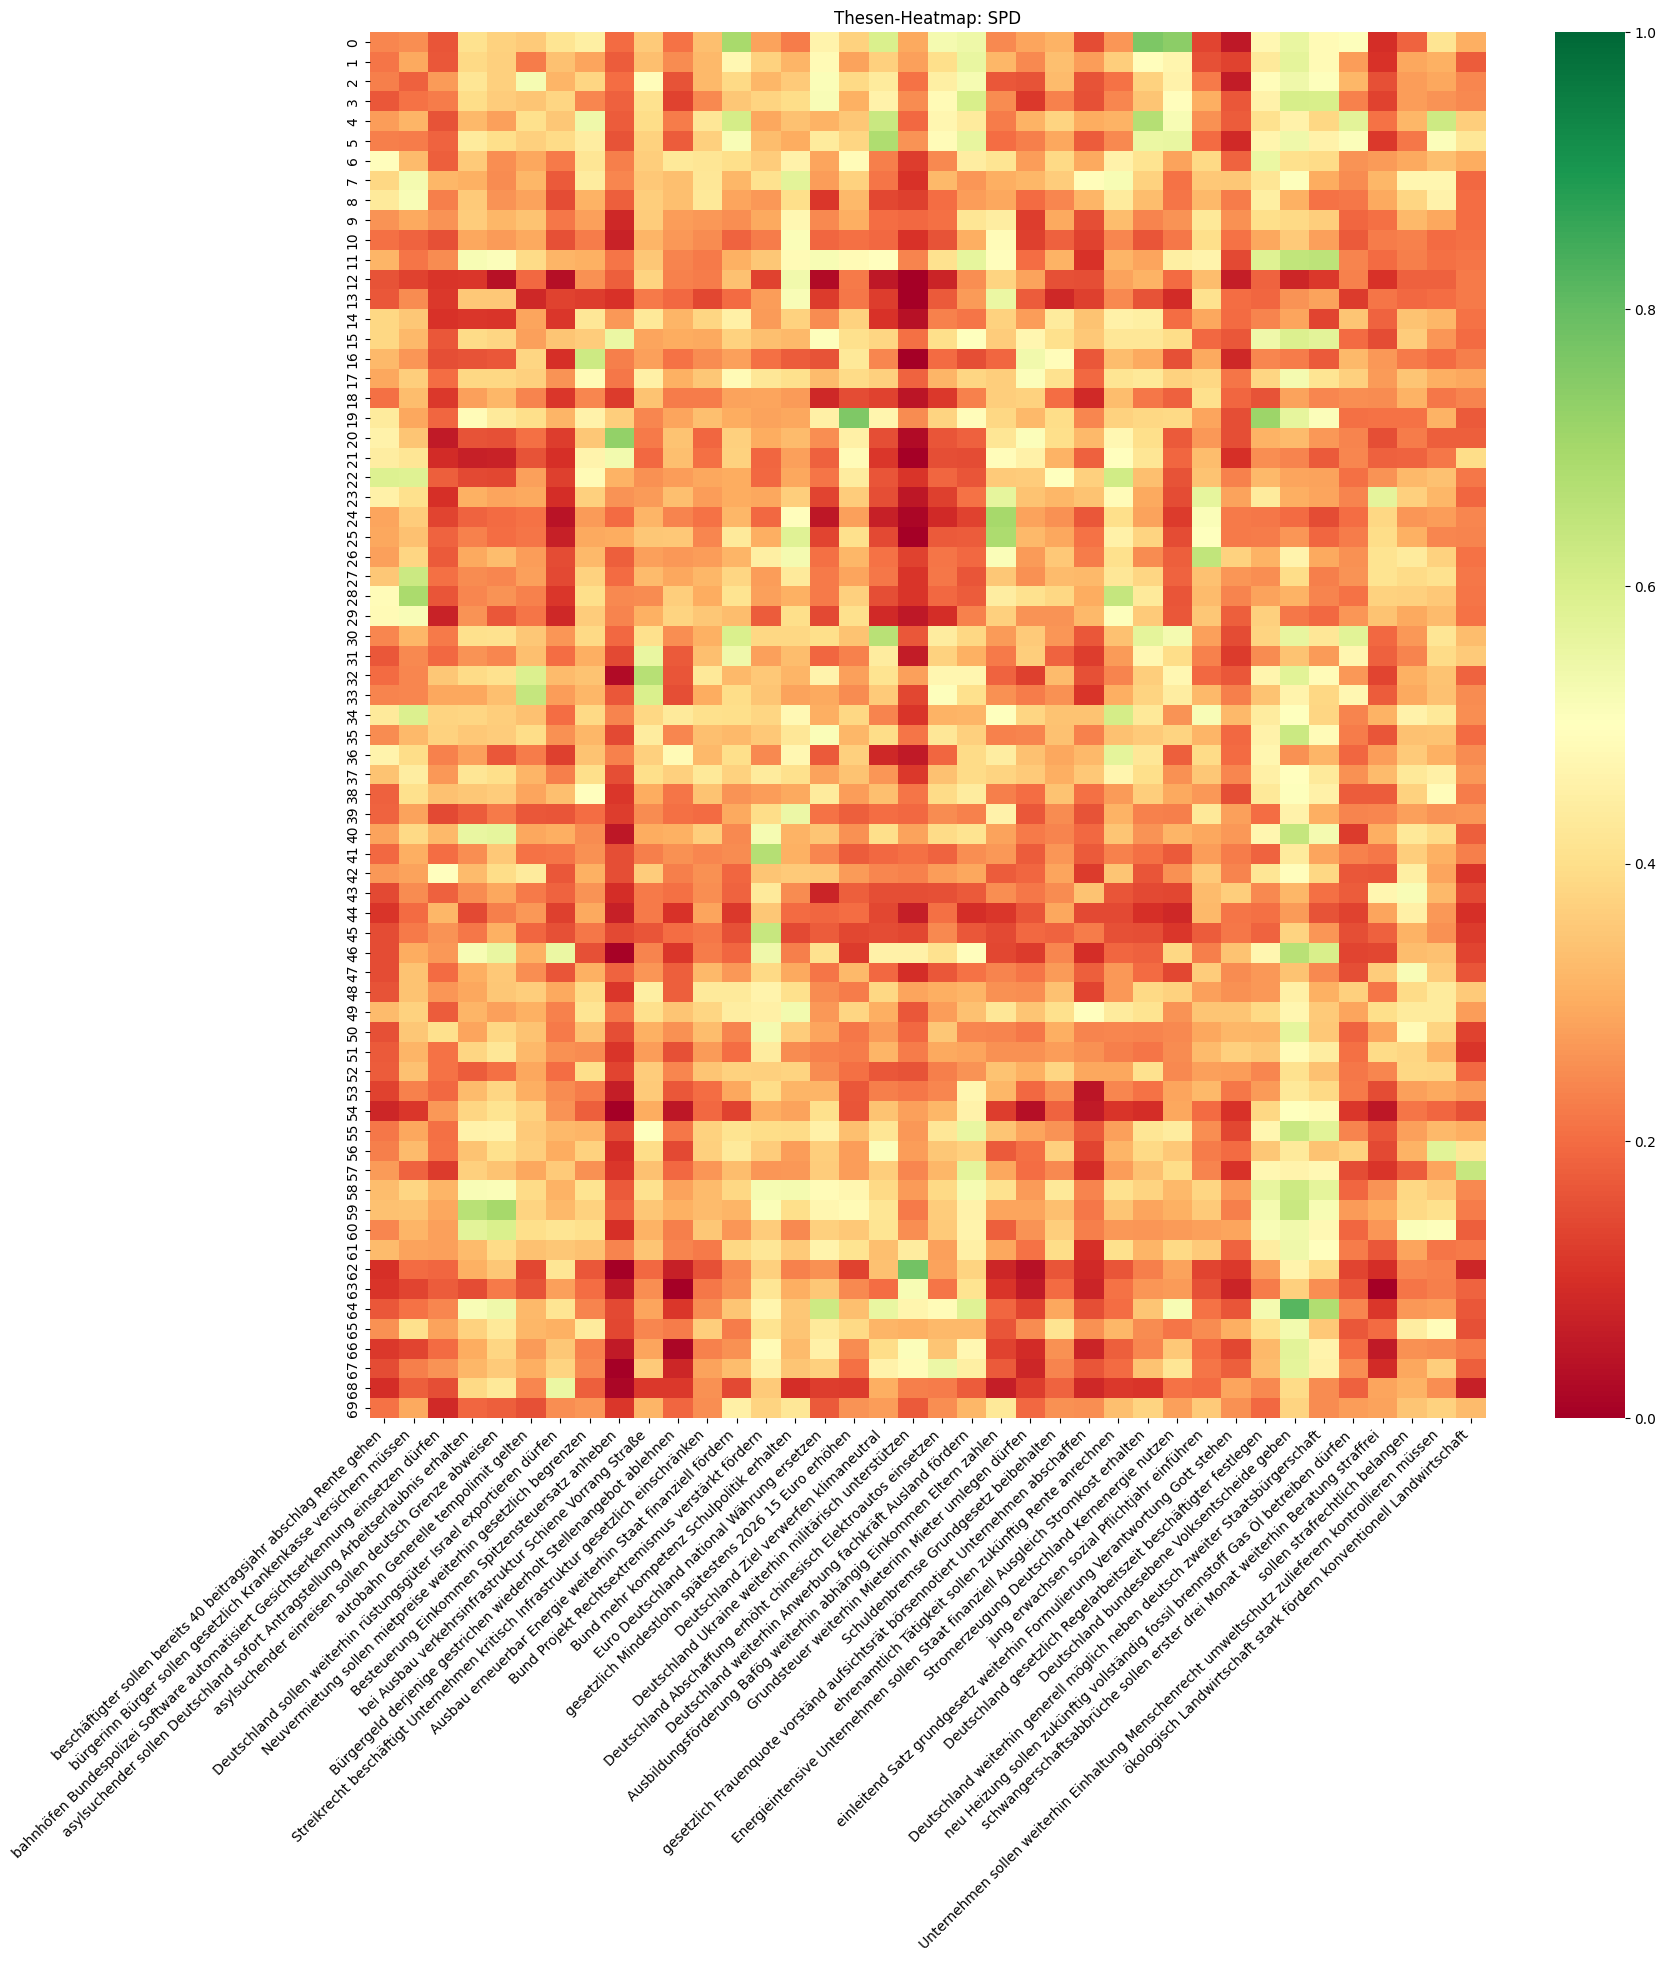

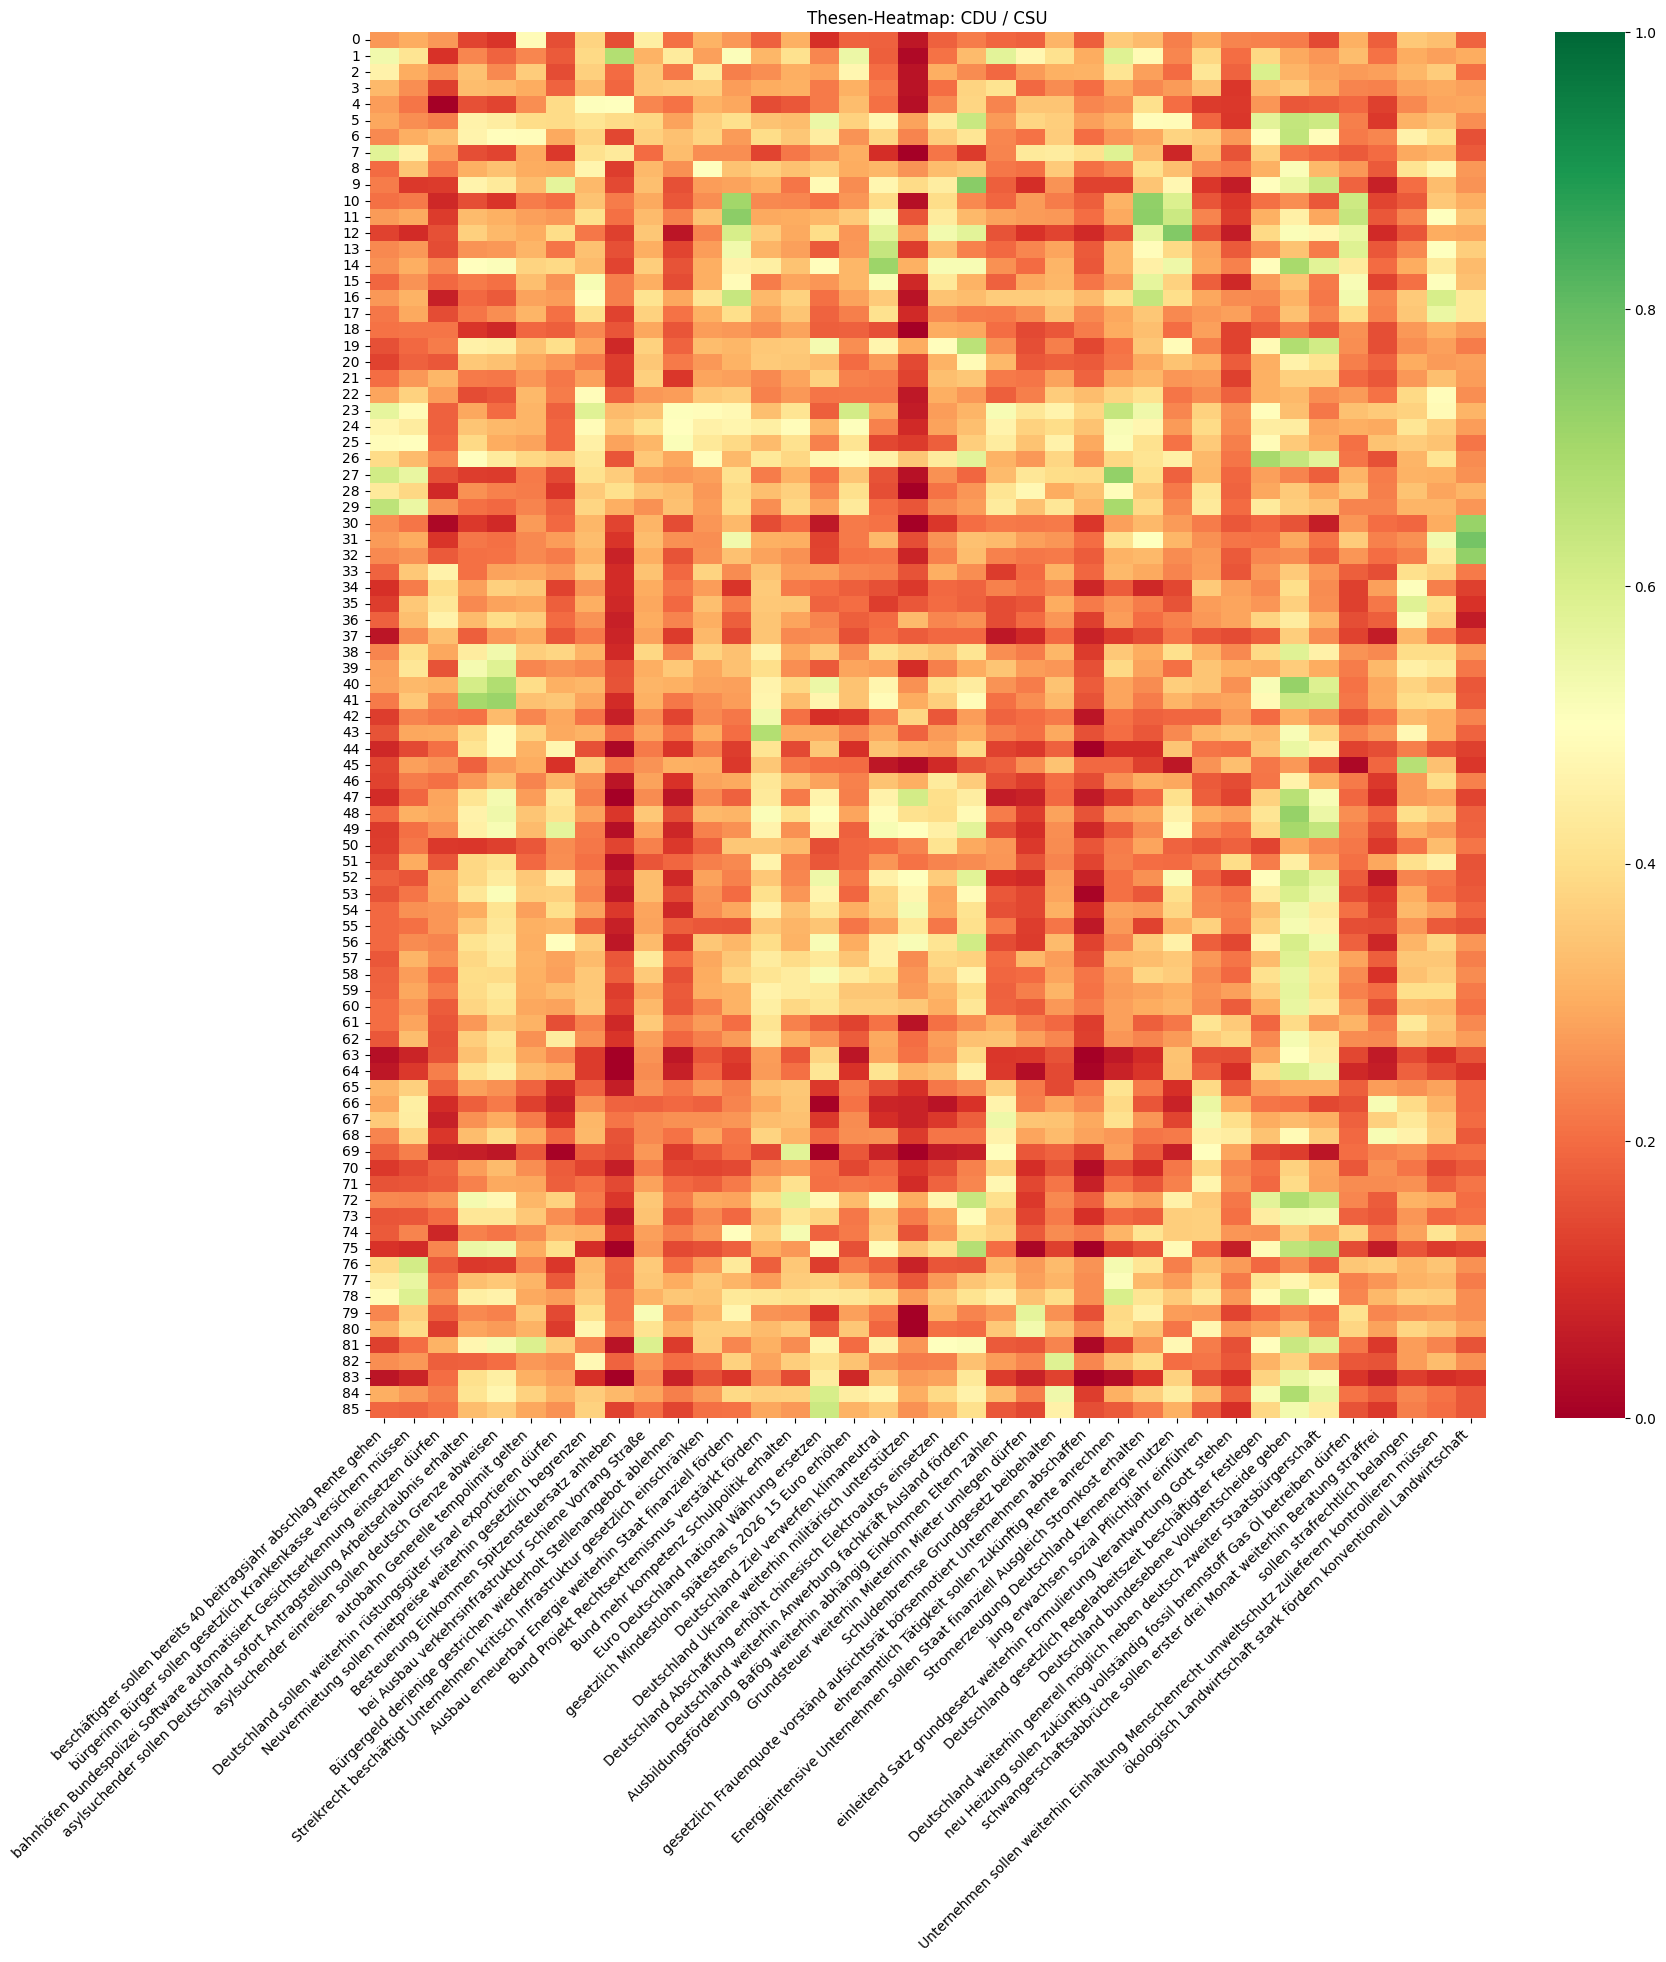

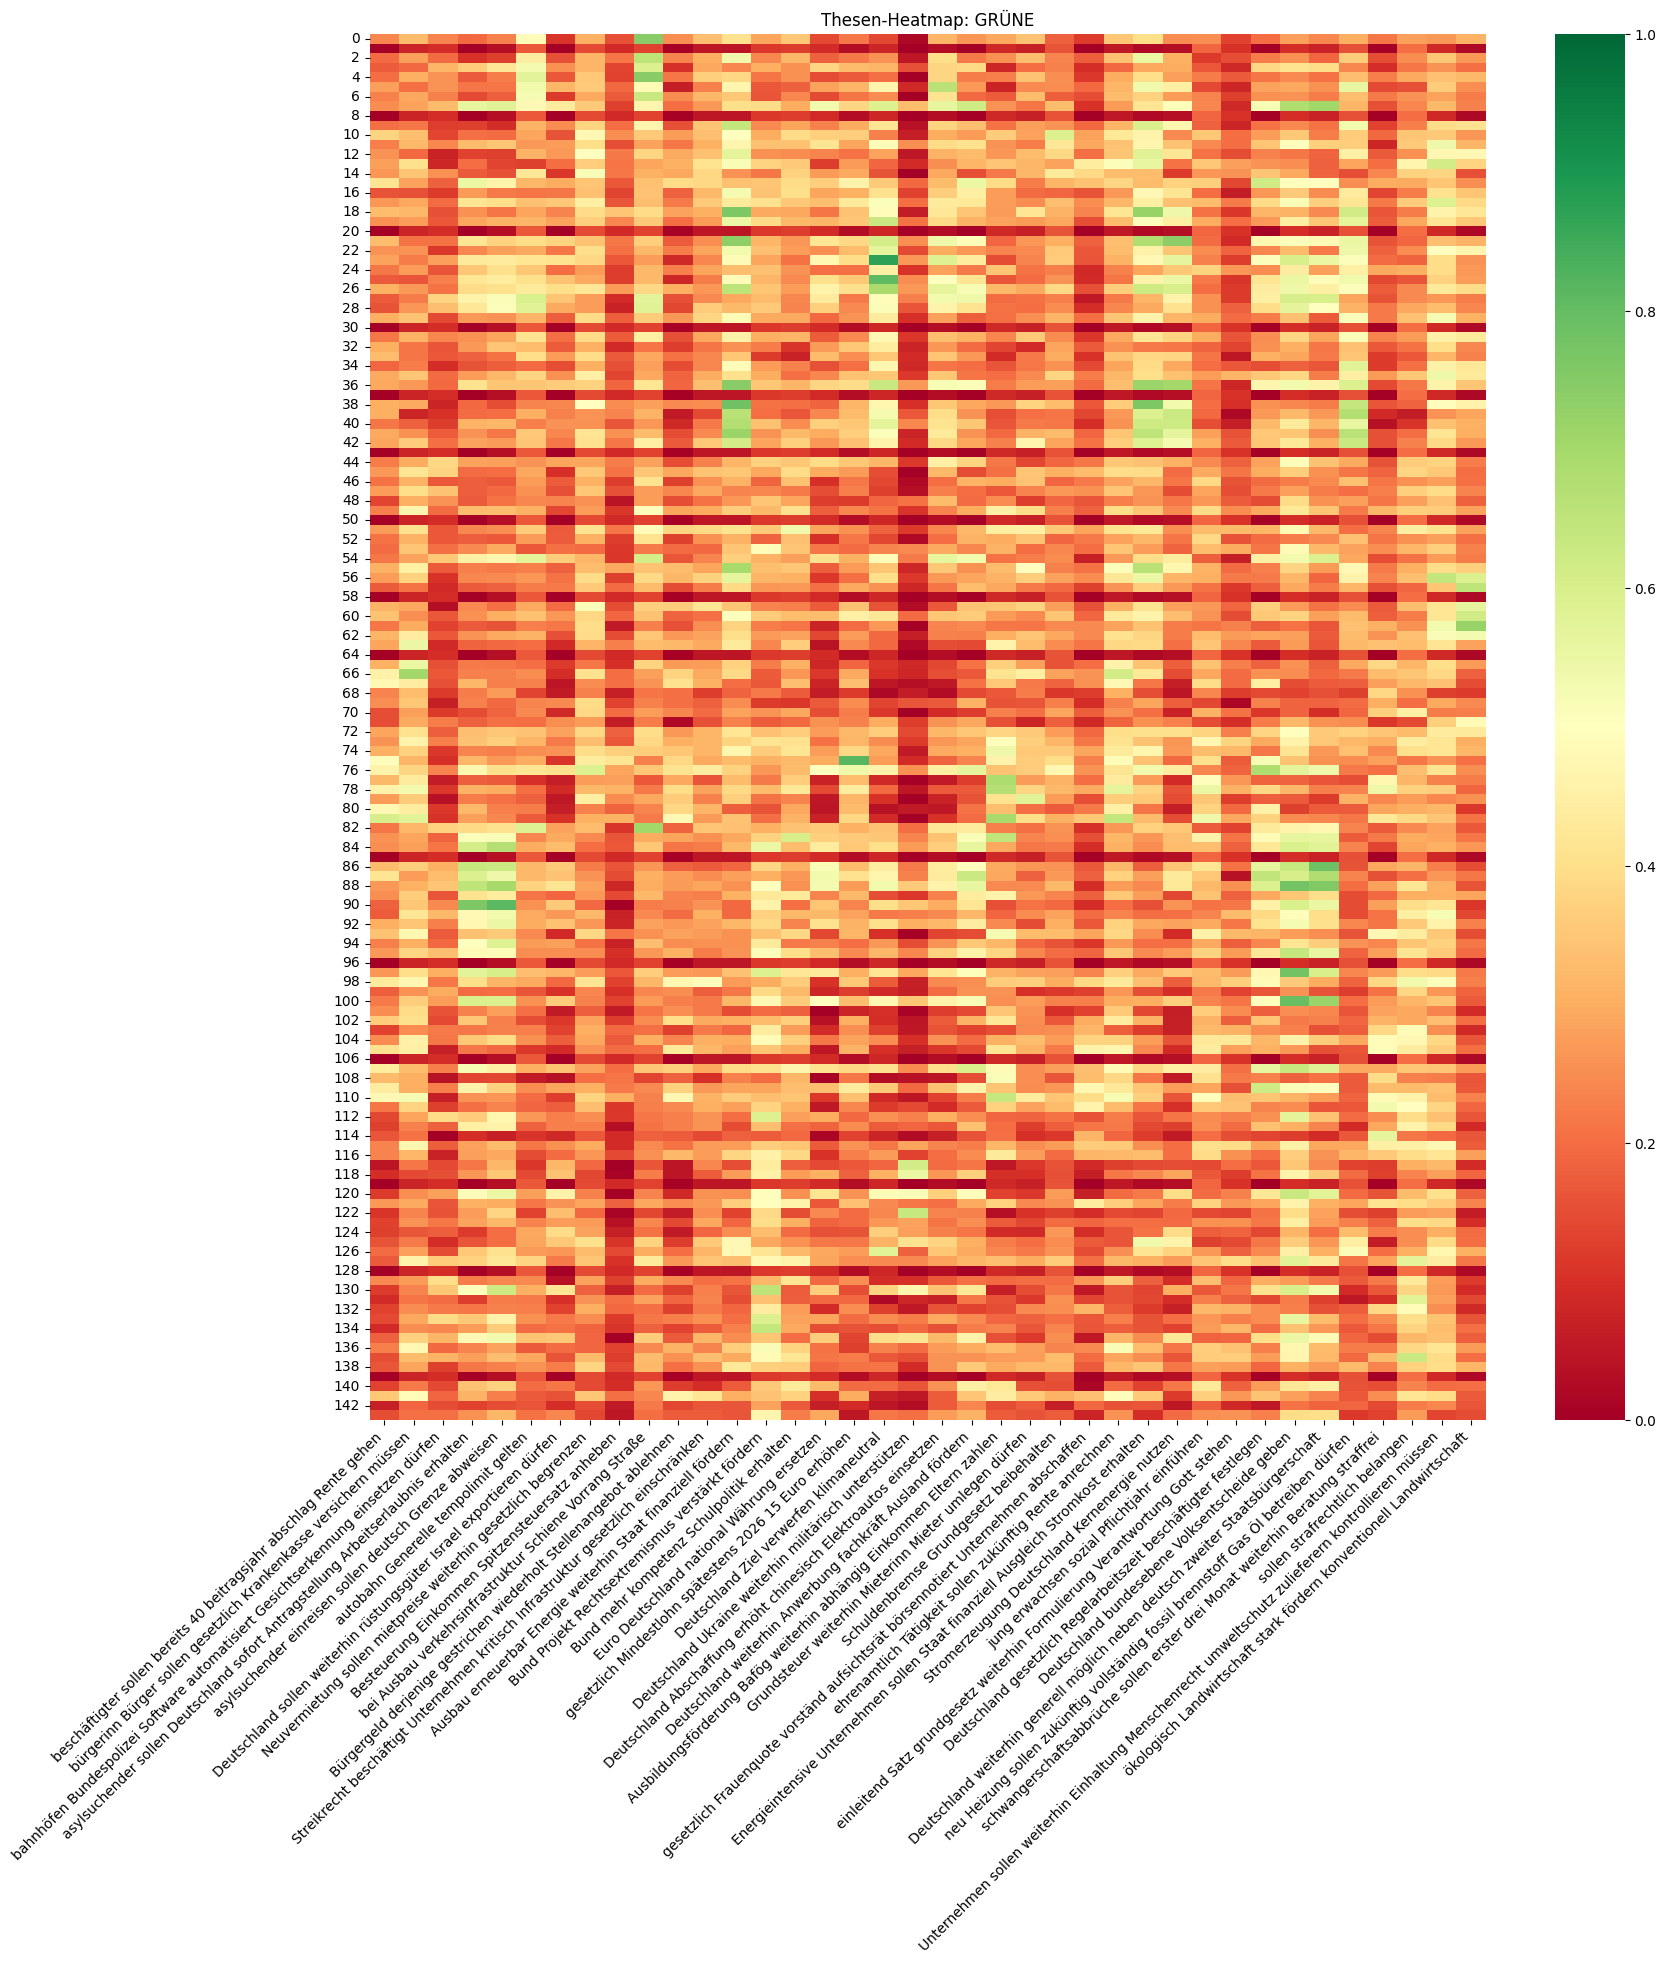

KeyboardInterrupt: 

In [ ]:
# Liste der Parteien und Thesen
parties_list = all_party_textes_df['Party'].unique().tolist()
labled_text_list = labled_theses_df['These_lemmatized'].tolist()
predicted_these_text_dfs_dict = {}
predicted_these_text_df = predicted_theses_df.copy()

# Schleife über die Parteien
for party_str in parties_list:
    # Filtern der Daten für die aktuelle Partei
    party_df = all_party_textes_df[all_party_textes_df['Party'] == party_str]
    
    # Entfernen von Zeilen mit NaN-Werten
    party_df = party_df.dropna()
    
    # Extrahieren der Thesen für die aktuelle Partei
    party_text_list = party_df['Text_lemmatized'].to_list()
    
    # Erstellung eines DataFrames zur Berechnung der Ähnlichkeiten
    similarity_df = pd.DataFrame(columns=['party_text'] + labled_text_list)

    # Berechnung der Ähnlichkeit für jede Partei-These
    for party_text in party_text_list:
        party_text_embedding = model.encode(party_text)
        row = [party_text]

        # Berechnung der Kosinusähnlichkeit für jede labelte These
        for label_text in labled_text_list:
            label_text_embedding = model.encode(label_text)
            similarity_score = (cosine_similarity(party_text_embedding.reshape(1, -1), label_text_embedding.reshape(1, -1))[0][0])
            row.append(similarity_score)

        similarity_df.loc[len(similarity_df)] = row

    # Visualisierung der Ähnlichkeiten als Heatmap
    plt.figure(figsize=(18, 18))
    sns.heatmap(similarity_df[labled_text_list],
                cmap='RdYlGn',
                annot=False,
                vmax=1,
                vmin=0,
                #yticklabels=party_df['These']
                )
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Thesen-Heatmap: {party_str}")
    plt.show()

    # Durchschnittliche Ähnlichkeit für jede Partei
    predicted_these_text_dfs_dict[party_str] = similarity_df
    predicted_these_text_df[party_str] = similarity_df[labled_text_list].max().tolist()
    

file_name_all_similaritys = f'paraphrase-multilingual-mpnet-base-v2_Theses_Text_all_similaritys.pkl' 
file_name_max_similaritys = f'paraphrase-multilingual-mpnet-base-v2_Theses_Text_max_similaritys.parquet' 


with open(file_name_all_similaritys, 'wb') as f:
    pickle.dump(predicted_these_text_dfs_dict, f)

predicted_these_text_df.to_parquet(file_name_max_similaritys, index=False)


In [ ]:
calc_prediction_scores_func(predicted_these_text_df, label_these_num_df)

,score,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,RMSE,0.570985,0.576083,0.555409,0.596040,0.59604,0.634072
1,MAE,0.473684,0.473684,0.456140,0.508772,0.50000,0.552632
2,R²,-2.207419,-2.087330,-2.072030,-2.684757,-2.37500,-3.160032


In [ ]:
predicted_these_text_df

,These,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,0.197280,0.500008,0.326008,0.398423,0.268547,0.306494
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,0.390431,0.460823,0.430797,0.437154,0.325244,0.487329
2,An Bahnhöfen soll die Bundespolizei Software z...,0.104083,0.322967,0.251852,0.197439,0.094315,0.274307
3,Asylsuchende sollen in Deutschland sofort nach...,0.204273,0.556813,0.341139,0.453674,0.318338,0.453685
4,"Asylsuchende, die über einen anderen EU-Staat ...",0.287283,0.570393,0.445605,0.488124,0.378472,0.445961
5,Auf allen Autobahnen soll ein generelles Tempo...,0.237328,0.518605,0.299764,0.290325,0.276073,0.498351
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,0.340289,0.432624,0.332886,0.470023,0.296665,0.522621
7,Bei Neuvermietungen sollen die Mietpreise weit...,0.310376,0.482463,0.447930,0.448431,0.379818,0.500345
8,Bei der Besteuerung von Einkommen soll der Spi...,0.309725,0.361109,0.370630,0.341633,0.469712,0.419132
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,0.294518,0.635704,0.405744,0.343092,0.322955,0.629296


In [ ]:
compare_df = pd.concat([predicted_these_text_df['These'], (predicted_these_text_df.select_dtypes(include='number')-label_these_num_df.select_dtypes(include='number'))], axis=1)

compare_df


,These,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,0.289804,0.190651,0.267291,0.335283,-0.278462,0.283109
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,0.342395,-0.286094,-0.238136,0.432123,-0.376852,0.387544
2,An Bahnhöfen soll die Bundespolizei Software z...,-0.434401,0.235920,0.271705,-0.459176,0.264656,0.298544
3,Asylsuchende sollen in Deutschland sofort nach...,0.370436,-0.255699,-0.314413,0.487750,-0.284700,0.164605
4,"Asylsuchende, die über einen anderen EU-Staat ...",-0.223627,0.519840,0.438173,-0.072912,0.441063,-0.021706
5,Auf allen Autobahnen soll ein generelles Tempo...,0.181402,-0.302404,-0.454652,0.396434,-0.315113,0.306670
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,-0.487609,-0.443639,-0.366299,-0.054546,0.136022,-0.235940
7,Bei Neuvermietungen sollen die Mietpreise weit...,-0.229195,-0.264401,-0.131228,0.421787,-0.109383,0.554337
8,Bei der Besteuerung von Einkommen soll der Spi...,0.241309,-0.463938,-0.188097,0.445110,-0.237598,0.367236
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,0.280029,-0.166132,-0.301109,0.634468,-0.112408,0.501183


In [ ]:
compare_df.drop(columns='These').mean()

CDU / CSU   -0.195748
GRÜNE       -0.005942
SPD         -0.145566
AfD         -0.056185
Die Linke   -0.148214
FDP          0.027012
dtype: float64

In [ ]:
compare_df.drop(columns='These').min().min()

np.float64(-0.7292503168185552)